In [1]:
!pip install tensorflow

In [2]:
pip install yfinance

In [3]:
import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta
import os

# 定义股票代码列表
tickers = [
    "600211.SS", "600233.SS", "600699.SS", "603882.SS",
    "603799.SS", "000821.SZ", "002073.SZ", "000980.SZ", "603179.SS",
    "601615.SS", "002240.SZ", "002459.SZ", "002364.SZ", "601689.SS"
]


# 定义数据下载的日期范围（例如，过去5年到昨天）
end_date = datetime.today() - timedelta(days=1)
start_date = end_date - timedelta(days=365 * 5)
start_str = start_date.strftime('%Y-%m-%d')
end_str = end_date.strftime('%Y-%m-%d')

# 定义保存 CSV 文件的目录
output_dir = 'stock_data_by_ticker'
# 创建目录（如果不存在）
os.makedirs(output_dir, exist_ok=True)

# 下载并保存每个股票的数据
for ticker in tickers:
    try:
        print(f"正在下载 {ticker} 从 {start_str} 到 {end_str} 的数据...")
        # 检查股票代码是否已包含市场后缀（.SS 或 .SZ），如果包含则直接使用
        if not (ticker.endswith(".SS") or ticker.endswith(".SZ")):
             # 如果没有后缀，尝试根据股票代码前缀推断市场并添加后缀
            if ticker.startswith(('6', '5')): # 上海证券交易所股票通常以 6 或 5 开头
                 formatted_ticker = f"{ticker}.SS"
            elif ticker.startswith(('0', '3')): # 深圳证券交易所股票通常以 0 或 3 开头
                 formatted_ticker = f"{ticker}.SZ"
            else:
                # 如果无法推断市场，则跳过该股票
                print(f"无法推断股票 {ticker} 的市场。跳过。")
                continue
            print(f"尝试使用格式化的股票代码下载: {formatted_ticker}")
        else:
            formatted_ticker = ticker # 如果已包含后缀，则直接使用


        # 使用 yfinance 下载数据
        data = yf.download(formatted_ticker, start=start_str, end=end_str)

        # 如果成功下载到数据
        if not data.empty:
            # 构建保存文件的完整路径
            filename = os.path.join(output_dir, f'{ticker}_data.csv')
            # 将数据保存为 CSV 文件
            data.to_csv(filename)
            print(f"股票 {ticker} 的数据已保存到 {filename}")
        else:
            # 如果没有下载到数据
            print(f"没有下载到股票 {formatted_ticker} 的数据。跳过保存。")

    except Exception as e:
        # 捕获下载过程中可能发生的错误
        print(f"下载股票 {formatted_ticker} 数据时发生错误: {e}")

# 添加代码用于打印每个已下载 CSV 文件的后五行以检查结果
print("\n--- 检查已下载的数据 ---")
# 遍历保存目录中的文件
for filename in os.listdir(output_dir):
    # 只处理以 "_data.csv" 结尾的文件
    if filename.endswith("_data.csv"):
        # 构建文件的完整路径
        filepath = os.path.join(output_dir, filename)
        try:
            # 读取 CSV 文件到 DataFrame
            df = pd.read_csv(filepath)
            # 从文件名中提取股票代码
            ticker = filename.replace("_data.csv", "")
            print(f"\n股票 {ticker} 的数据预览（后5行）:")
            # 打印 DataFrame 的后5行
            print(df.tail())
        except Exception as e:
            # 捕获读取文件时可能发生的错误
            print(f"读取 {filename} 文件时发生错误: {e}")

正在下载 600211.SS 从 2020-09-08 到 2025-09-07 的数据...


/tmp/ipython-input-802316738.py:46: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(formatted_ticker, start=start_str, end=end_str)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-802316738.py:46: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(formatted_ticker, start=start_str, end=end_str)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-802316738.py:46: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(formatted_ticker, start=start_str, end=end_str)


股票 600211.SS 的数据已保存到 stock_data_by_ticker/600211.SS_data.csv
正在下载 600233.SS 从 2020-09-08 到 2025-09-07 的数据...
股票 600233.SS 的数据已保存到 stock_data_by_ticker/600233.SS_data.csv
正在下载 600699.SS 从 2020-09-08 到 2025-09-07 的数据...


[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-802316738.py:46: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(formatted_ticker, start=start_str, end=end_str)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-802316738.py:46: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(formatted_ticker, start=start_str, end=end_str)


股票 600699.SS 的数据已保存到 stock_data_by_ticker/600699.SS_data.csv
正在下载 603882.SS 从 2020-09-08 到 2025-09-07 的数据...
股票 603882.SS 的数据已保存到 stock_data_by_ticker/603882.SS_data.csv
正在下载 603799.SS 从 2020-09-08 到 2025-09-07 的数据...


...

股票 603179.SS 的数据已保存到 stock_data_by_ticker/603179.SS_data.csv
正在下载 601615.SS 从 2020-09-08 到 2025-09-07 的数据...
股票 601615.SS 的数据已保存到 stock_data_by_ticker/601615.SS_data.csv
正在下载 002240.SZ 从 2020-09-08 到 2025-09-07 的数据...


[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-802316738.py:46: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(formatted_ticker, start=start_str, end=end_str)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-802316738.py:46: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(formatted_ticker, start=start_str, end=end_str)


股票 002240.SZ 的数据已保存到 stock_data_by_ticker/002240.SZ_data.csv
正在下载 002459.SZ 从 2020-09-08 到 2025-09-07 的数据...
股票 002459.SZ 的数据已保存到 stock_data_by_ticker/002459.SZ_data.csv
正在下载 002364.SZ 从 2020-09-08 到 2025-09-07 的数据...


[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-802316738.py:46: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(formatted_ticker, start=start_str, end=end_str)
[*********************100%***********************]  1 of 1 completed


股票 002364.SZ 的数据已保存到 stock_data_by_ticker/002364.SZ_data.csv
正在下载 601689.SS 从 2020-09-08 到 2025-09-07 的数据...
股票 601689.SS 的数据已保存到 stock_data_by_ticker/601689.SS_data.csv

--- 检查已下载的数据 ---

股票 002459.SZ 的数据预览（后5行）:
           Price               Close                High                 Low  \
1209  2025-09-01  12.720000267028809  12.800000190734863  12.329999923706055   
1210  2025-09-02  12.239999771118164  12.850000381469727  12.199999809265137   
1211  2025-09-03                12.5  12.680000305175781  12.149999618530273   
1212  2025-09-04                13.5               13.75  12.550000190734863   
1213  2025-09-05  14.010000228881836  14.050000190734863  13.220000267028809   

                    Open     Volume  
1209  12.619999885559082   65813206  
1210  12.680000305175781   57922966  
1211  12.369999885559082   90659787  
1212  12.550000190734863  222263689  
1213               13.25  183544239  

股票 000980.SZ 的数据预览（后5行）:
           Price               Close               

In [4]:
import pandas as pd
import os

# Directory containing the individual ticker CSV files
output_dir = 'stock_data_by_ticker' # 存储单个股票CSV文件的目录

# List to hold DataFrames
all_dfs = [] # 用于存储DataFrame的列表

# Read each CSV and append to the list
for filename in os.listdir(output_dir): # 遍历目录中的每个文件
    # Only process files ending with "_data.csv"
    if filename.endswith("_data.csv"): # 只处理以 "_data.csv" 结尾的文件
        # Construct the full file path
        filepath = os.path.join(output_dir, filename) # 构建文件的完整路径
        try:
            # Try reading assuming the first row is the header
            df = pd.read_csv(filepath) # 尝试读取CSV文件，假设第一行是表头

            # Check if the first column name is 'Date' (standard) or 'Price' (seen in some outputs)
            # If it's 'Price', the actual header is likely the second row, and data starts from the third
            if df.columns[0] == 'Price': # 检查第一列是否是 'Price'
                 # Read again, skipping the first two rows and setting the header to the third row
                df = pd.read_csv(filepath, skiprows=[0, 1], header=0) # 重新读取，跳过前两行，并将第三行设置为表头
                # Assuming the columns in this case are Date, Open, High, Low, Close, Volume
                df.columns = ['Date', 'Open', 'High', 'Low', 'Close', 'Volume'] # 设置列名
            elif df.columns[0] != 'Date':
                 # If the first column is neither 'Date' nor 'Price', something else is wrong, skip for now
                 print(f"Skipping {filename} due to unexpected column structure: {df.columns}") # 由于意外的列结构，跳过文件
                 continue

            # Extract ticker from filename (assuming format like "TICKER_data.csv")
            ticker = filename.replace("_data.csv", "") # 从文件名中提取股票代码
            df['Ticker'] = ticker # 添加 'Ticker' 列
            all_dfs.append(df) # 将DataFrame添加到列表中
        except Exception as e:
            print(f"Error reading {filename}: {e}") # 读取文件时发生错误

# Concatenate all DataFrames into a single DataFrame
combined_df = pd.concat(all_dfs, ignore_index=True) # 将所有DataFrame合并为一个

# Convert 'Date' column to datetime and sort
combined_df['Date'] = pd.to_datetime(combined_df['Date']) # 将 'Date' 列转换为日期时间格式
combined_df.sort_values(by=['Ticker', 'Date'], inplace=True) # 按股票代码和日期排序

print("Combined DataFrame preview:") # 打印合并后的DataFrame预览
print(combined_df.head()) # 显示前几行
print("\nCombined DataFrame info:") # 打印合并后的DataFrame信息
combined_df.info() # 显示DataFrame的详细信息

Combined DataFrame preview:
            Date      Open      High       Low     Close   Volume     Ticker
13332 2020-09-08  6.391251  6.420840  6.272894  6.410977  6954978  000821.SZ
13333 2020-09-09  6.381387  6.470155  6.272894  6.302483  7428641  000821.SZ
13334 2020-09-10  6.154537  6.430703  6.115085  6.430703  7130767  000821.SZ
13335 2020-09-11  6.292621  6.351799  6.046045  6.095360  5493157  000821.SZ
13336 2020-09-14  6.312346  6.341935  6.233442  6.282757  3040765  000821.SZ

Combined DataFrame info:
<class 'pandas.core.frame.DataFrame'>
Index: 16968 entries, 13332 to 10907
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    16968 non-null  datetime64[ns]
 1   Open    16968 non-null  float64       
 2   High    16968 non-null  float64       
 3   Low     16968 non-null  float64       
 4   Close   16968 non-null  float64       
 5   Volume  16968 non-null  int64         
 6   Ticker  16968 non-nu

In [5]:
import numpy as np
import pandas as pd # 导入 pandas 库，虽然之前已导入，但在此单元格中大量使用

# 重命名列以方便访问 (注意: 根据之前的输出，这些列可能已经有了正确的名称，此行可能不是必需的)
# 假设列的顺序是: Date, Open, High, Low, Close, Volume, Ticker，然后是技术指标计算的中间列
# 我们只重命名已知名称的前 7 列
# combined_df.columns = ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Ticker'] + list(combined_df.columns[7:])


# 将必要的列转换为数值类型，强制转换错误为 NaN
for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
    combined_df[col] = pd.to_numeric(combined_df[col], errors='coerce')

# 删除由于强制转换或技术指标计算可能产生的缺失值行
combined_df.dropna(inplace=True)


# 计算 MACD 和信号线指标
def compute_macd(df, fast=12, slow=26, signal=9):
    # 计算快速 EMA (指数移动平均)
    df['EMA_fast'] = df.groupby('Ticker')['Close'].transform(lambda x: x.ewm(span=fast, adjust=False).mean())
    # 计算慢速 EMA
    df['EMA_slow'] = df.groupby('Ticker')['Close'].transform(lambda x: x.ewm(span=slow, adjust=False).mean())
    # 计算 MACD 线
    df['MACD'] = df['EMA_fast'] - df['EMA_slow']
    # 计算 MACD 信号线 (MACD 的 EMA)
    df['MACD_signal'] = df.groupby('Ticker')['MACD'].transform(lambda x: x.ewm(span=signal, adjust=False).mean())
    return df

# 计算 RSI (相对强弱指数) 指标
def compute_rsi(df, period=14):
    # 计算收盘价的日变化
    df['Close_diff'] = df.groupby('Ticker')['Close'].diff()
    # 计算收益 (价格上涨)
    df['gain'] = df['Close_diff'].where(df['Close_diff'] > 0, 0)
    # 计算损失 (价格下跌)，取绝对值
    df['loss'] = -df['Close_diff'].where(df['Close_diff'] < 0, 0)
    # 计算平均收益 (滚动平均)
    df['avg_gain'] = df.groupby('Ticker')['gain'].transform(lambda x: x.rolling(window=period).mean())
    # 计算平均损失 (滚动平均)
    df['avg_loss'] = df.groupby('Ticker')['loss'].transform(lambda x: x.rolling(window=period).mean())
    # 计算相对强度 (避免除以零)
    df['rs'] = df['avg_gain'] / df['avg_loss'].replace(0, np.nan)
    # 计算 RSI
    df['RSI'] = 100 - (100 / (1 + df['rs']))
    # 删除中间计算列
    df = df.drop(columns=['Close_diff', 'gain', 'loss', 'avg_gain', 'avg_loss', 'rs'])
    return df


# 添加技术指标到 DataFrame
def add_technical_indicators(df):
    df = compute_macd(df) # 计算并添加 MACD
    df = compute_rsi(df) # 计算并添加 RSI
    df.dropna(inplace=True) # 删除因滚动计算产生的 NaN 行
    return df

# 应用技术指标计算
combined_df = add_technical_indicators(combined_df)

# 添加周期性时间特征
combined_df['DayOfWeek'] = combined_df['Date'].dt.dayofweek  # 星期几 (周一=0, 周日=6)
combined_df['Month'] = combined_df['Date'].dt.month # 月份

# 转换为周期性特征 (正弦/余弦)
combined_df['Day_sin'] = np.sin(2 * np.pi * combined_df['DayOfWeek'] / 7) # 星期几的正弦分量
combined_df['Day_cos'] = np.cos(2 * np.pi * combined_df['DayOfWeek'] / 7) # 星期几的余弦分量
combined_df['Month_sin'] = np.sin(2 * np.pi * combined_df['Month'] / 12) # 月份的正弦分量
combined_df['Month_cos'] = np.cos(2 * np.pi * combined_df['Month'] / 12) # 月份的余弦分量

print("\nDataFrame 添加技术指标和周期性特征后:")
print(combined_df.head())
print("\n预处理后的 DataFrame 信息:")
combined_df.info()


DataFrame 添加技术指标和周期性特征后:
            Date      Open      High       Low     Close   Volume     Ticker  \
13345 2020-09-25  6.065770  6.174264  5.996729  6.174264  2659905  000821.SZ   
13346 2020-09-28  6.075633  6.105222  6.026318  6.065770  1979556  000821.SZ   
13347 2020-09-29  6.134811  6.164401  6.075633  6.105223  1590310  000821.SZ   
13348 2020-09-30  6.124949  6.164401  6.095359  6.154537  2093600  000821.SZ   
13349 2020-10-09  6.401114  6.529333  6.312346  6.410977  8465198  000821.SZ   

       EMA_fast  EMA_slow      MACD  MACD_signal        RSI  DayOfWeek  Month  \
13345  6.287270  6.327954 -0.040685    -0.029337  40.769222          4      9   
13346  6.253193  6.308533 -0.055340    -0.034538  37.588641          0      9   
13347  6.230428  6.293473 -0.063045    -0.040239  42.537319          1      9   
13348  6.218753  6.283182 -0.064429    -0.045077  38.888870          2      9   
13349  6.248326  6.292648 -0.044322    -0.044926  63.559332          4     10   

      

In [6]:
from sklearn.model_selection import train_test_split # 导入用于数据分割的库
from tensorflow.keras.models import Sequential # 导入Sequential模型
from tensorflow.keras.layers import LSTM, Dropout, Dense # 导入LSTM, Dropout, Dense层
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint # 导入回调函数
from sklearn.preprocessing import MinMaxScaler # 导入MinMaxScaler用于数据缩放
import numpy as np # 导入numpy库

# 定义LSTM序列的窗口大小
window_size = 60  # 示例: 使用过去60天的数据预测下一天

# 准备用于LSTM的数据
X, y, tickers_list, y_dates = [], [], [], []

# 定义要使用的特征 (排除日期和股票代码以及临时列)
features = [col for col in combined_df.columns if col not in ['Date', 'Ticker', 'EMA_fast', 'EMA_slow', 'MACD', 'MACD_signal', 'RSI', 'DayOfWeek', 'Month']]
# 添加计算出的技术指标和周期性时间特征
features.extend(['EMA_fast', 'EMA_slow', 'MACD', 'MACD_signal', 'RSI', 'Day_sin', 'Day_cos', 'Month_sin', 'Month_cos'])


# 缩放特征
# 在整个combined_df上拟合Scaler以避免数据泄露
scaler = MinMaxScaler(feature_range=(0, 1))
combined_df_scaled = scaler.fit_transform(combined_df[features])


# 为每个股票创建序列
for ticker in combined_df['Ticker'].unique():
    ticker_data = combined_df[combined_df['Ticker'] == ticker].copy()
    ticker_data_scaled = combined_df_scaled[combined_df['Ticker'] == ticker].copy()


    # 确保有足够的数据来创建至少一个序列
    if len(ticker_data_scaled) >= window_size + 1:
        for i in range(len(ticker_data_scaled) - window_size):
            # X是window_size天数的特征序列
            X.append(ticker_data_scaled[i:(i + window_size), :])
            # y是下一天的'Close'价格
            y.append(ticker_data_scaled[i + window_size, features.index('Close')])
            # 存储相应的股票代码和日期，用于后续分析/绘图
            tickers_list.append(ticker)
            y_dates.append(ticker_data['Date'].iloc[i + window_size])


# 将列表转换为numpy数组
X = np.array(X)
y = np.array(y)
tickers_list = np.array(tickers_list)
y_dates = pd.to_datetime(y_dates)


# 分割数据，同时保持同一股票的序列在一起
# 这里不能简单地使用shuffle=True的train_test_split，因为它会混合不同股票的序列。
# 对于鲁棒的评估，手动分割或使用GroupShuffleSplit更合适。
# 但是，为了简化和演示联合训练，如果数据已经按股票和日期排序，我们将使用基于时间的分割。

# 确定分割点 (例如，80%用于训练)
split_ratio = 0.8
split_index = int(len(X) * split_ratio)

X_train, X_val = X[:split_index], X[split_index:]
y_train, y_val = y[:split_index], y[split_index:]
tickers_train, tickers_val = tickers_list[:split_index], tickers_list[split_index:]
y_dates_train, y_dates_val = y_dates[:split_index], y_dates[split_index:]


print("X_train的形状:", X_train.shape)
print("X_val的形状:", X_val.shape)
print("y_train的形状:", y_train.shape)
print("y_val的形状:", y_val.shape)

X_train的形状: (12751, 60, 18)
X_val的形状: (3188, 60, 18)
y_train的形状: (12751,)
y_val的形状: (3188,)


In [7]:
from sklearn.model_selection import train_test_split # 导入 train_test_split 用于数据分割，尽管在此单元格中未直接使用
from tensorflow.keras.models import Sequential # 导入 Sequential 模型，用于构建线性堆叠的神经网络层
from tensorflow.keras.layers import LSTM, Dropout, Dense # 导入 LSTM、Dropout 和 Dense 层
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint # 导入 EarlyStopping 和 ModelCheckpoint 回调函数
from sklearn.preprocessing import MinMaxScaler # 导入 MinMaxScaler，尽管在此单元格中未直接使用
import numpy as np # 导入 numpy 库用于数值计算

# 构建 LSTM 模型
def build_lstm_model(input_shape):
    model = Sequential() # 初始化 Sequential 模型
    # 添加第一个 LSTM 层，包含 64 个单元，return_sequences=True 表示输出每个时间步的隐藏状态
    model.add(LSTM(64, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2)) # 添加 Dropout 层，丢弃 20% 的神经元以防止过拟合
    # 添加第二个 LSTM 层，包含 32 个单元，默认 return_sequences=False，只输出最后一个时间步的隐藏状态
    model.add(LSTM(32))
    model.add(Dropout(0.2)) # 添加另一个 Dropout 层
    model.add(Dense(1)) # 添加一个 Dense (全连接) 输出层，输出一个值 (预测的收盘价)
    model.compile(optimizer='adam', loss='mse') # 编译模型，指定优化器和损失函数
    return model # 返回构建好的模型

# 构建模型，输入形状根据训练数据 X_train 确定
model = build_lstm_model((X_train.shape[1], X_train.shape[2]))

# 回调函数 (可选)
# EarlyStopping: 当验证集损失连续 10 个 epoch 没有改善时停止训练，并恢复最佳权重
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
# ModelCheckpoint: 保存验证集损失最佳的模型权重到文件 'best_combined_model.h5'
checkpoint = ModelCheckpoint('best_combined_model.h5', save_best_only=True)

# 模型训练
history = model.fit(
    X_train, y_train, # 训练数据
    epochs=50, # 最大训练轮数
    batch_size=32, # 每次梯度更新的样本数
    validation_data=(X_val, y_val), # 验证数据，用于评估模型性能
    callbacks=[early_stop, checkpoint], # 训练期间使用的回调函数列表
    verbose=1 # 显示训练进度和详细信息
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0037

399/399 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 0.0037 - val_loss: 0.0025
Epoch 2/50
396/399 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4.2533e-04

399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 4.2507e-04 - val_loss: 0.0018
Epoch 3/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 2.8602e-04 - val_loss: 0.0033
Epoch 4/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 2.3952e-04 - val_loss: 0.0022
Epoch 5/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.0643e-04

399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 2.0643e-04 - val_loss: 0.0016
Epoch 6/50
397/399 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.8201e-04

...

399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 1.4861e-04 - val_loss: 6.8272e-04
Epoch 14/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 1.3166e-04 - val_loss: 0.0014
Epoch 15/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 1.1821e-04 - val_loss: 6.9304e-04
Epoch 16/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 1.2318e-04 - val_loss: 0.0012
Epoch 17/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 1.3448e-04 - val_loss: 0.0012
Epoch 18/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 1.1722e-04 - val_loss: 9.5460e-04
Epoch 19/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 1.1012e-04 - val_loss: 0.0011
Epoch 20/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 1.1242e-04 - val_loss: 8.2718e-04
Epoch 21/50
397/399 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.0776e-04

399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 1.0777e-04 - val_loss: 5.3766e-04
Epoch 22/50
393/399 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.0598e-04

399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 1.0592e-04 - val_loss: 4.2488e-04
Epoch 23/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 1.0110e-04 - val_loss: 7.6823e-04
Epoch 24/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 1.0010e-04 - val_loss: 6.1752e-04
Epoch 25/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 1.0447e-04 - val_loss: 6.1628e-04
Epoch 26/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 9.9518e-05 - val_loss: 6.3972e-04
Epoch 27/50
393/399 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 9.7416e-05

399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 9.7433e-05 - val_loss: 3.1522e-04
Epoch 28/50
395/399 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.0299e-04

399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 1.0294e-04 - val_loss: 1.7214e-04
Epoch 29/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 9.6902e-05 - val_loss: 8.5779e-04
Epoch 30/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 9.2132e-05 - val_loss: 8.4749e-04
Epoch 31/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 9.5389e-05 - val_loss: 0.0014
Epoch 32/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 1.0028e-04 - val_loss: 0.0012
Epoch 33/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 9.4232e-05 - val_loss: 3.6265e-04
Epoch 34/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 9.0956e-05 - val_loss: 3.1404e-04
Epoch 35/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 9.7285e-05 - val_loss: 6.3573e-04
Epoch 36/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 9.3902e-05 - val_loss: 8.9267e-04
Epoch 37/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 9.7483e-05 - val_loss: 9.6780e-04
Epoch 38/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 9.145

In [8]:
# 模型预测
y_pred = model.predict(X_val)

# 逆缩放预测结果以进行评估
# 我们需要一个专门针对 'Close' 价格进行拟合的缩放器，或者使用原始缩放器并在逆变换后提取 'Close' 列
# 为了准确的逆缩放，我们将重新拟合一个针对整个 combined_df 中 'Close' 价格的缩放器
close_scaler = MinMaxScaler()
close_scaler.fit(combined_df['Close'].values.reshape(-1, 1))

# 对验证集的真实值和预测值进行逆缩放
y_val_rescaled = close_scaler.inverse_transform(y_val.reshape(-1, 1))
y_pred_rescaled = close_scaler.inverse_transform(y_pred)

# 打印逆缩放后的形状以进行检查
print("y_val_rescaled 的形状:", y_val_rescaled.shape)
print("y_pred_rescaled 的形状:", y_pred_rescaled.shape)

100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
y_val_rescaled 的形状: (3188, 1)
y_pred_rescaled 的形状: (3188, 1)


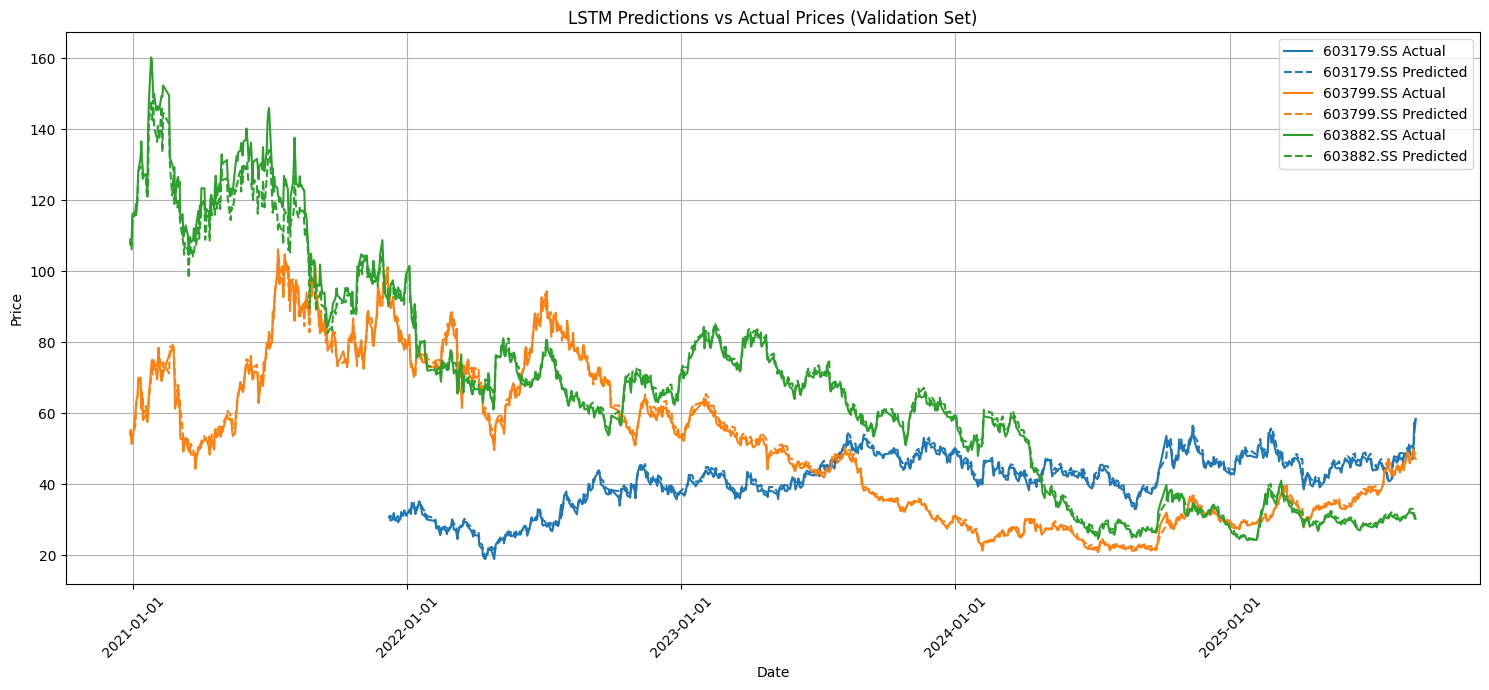

In [9]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib

# 配置 matplotlib 以支持中文显示
# matplotlib.rcParams['font.sans-serif'] = ['SimHei']  # 或者其他支持中文的字体，如 'WenQuanYi Zen Hei'
matplotlib.rcParams['axes.unicode_minus'] = False # 确保负号正确显示

# 绘制验证集的预测结果与实际值对比图
def plot_validation_predictions(y_true, y_pred, dates, tickers, title='LSTM Predictions vs Actual Prices (Validation Set)'):
    plt.figure(figsize=(15, 7)) # 创建一个新的图，设置图的大小

    unique_tickers = np.unique(tickers) # 获取验证集中唯一的股票代码
    n_tickers = len(unique_tickers) # 计算唯一的股票代码数量
    cmap = plt.get_cmap('tab10') # 获取一个颜色映射，用于为不同的股票分配颜色

    # 遍历每个唯一的股票代码进行绘图
    for i, ticker in enumerate(unique_tickers):
        ticker_mask = (tickers == ticker) # 创建一个布尔掩码，用于选择当前股票的数据
        # 绘制实际价格曲线
        plt.plot(dates[ticker_mask], y_true[ticker_mask], label=f'{ticker} Actual', color=cmap(i), linestyle='-')
        # 绘制预测价格曲线
        plt.plot(dates[ticker_mask], y_pred[ticker_mask], label=f'{ticker} Predicted', color=cmap(i), linestyle='--')


    plt.title(title) # 设置图的标题
    plt.xlabel('Date') # 设置x轴标签
    plt.ylabel('Price') # 设置y轴标签
    plt.legend() # 显示图例
    plt.grid(True) # 显示网格
    # 配置x轴日期格式
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator()) # 自动设置日期刻度的位置
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d')) # 设置日期显示格式为年-月-日
    plt.xticks(rotation=45) # 旋转x轴刻度标签，避免重叠
    plt.tight_layout() # 调整布局，使图表元素紧凑
    plt.show() # 显示图表

# 由于 y_dates_val 和 tickers_val 对应于验证集数据
# 调用函数绘制验证集的实际值与预测值对比图
plot_validation_predictions(y_val_rescaled.flatten(), y_pred_rescaled.flatten(), y_dates_val, tickers_val)


正在为 000821.SZ 生成未来预测...
股票 000821.SZ 的未来预测:


,Date,Predicted Close
0,2025-09-06,13.760315
1,2025-09-07,13.846579
2,2025-09-08,13.923963
3,2025-09-09,14.008766
4,2025-09-10,14.108557
5,2025-09-11,14.228318
6,2025-09-12,14.367876


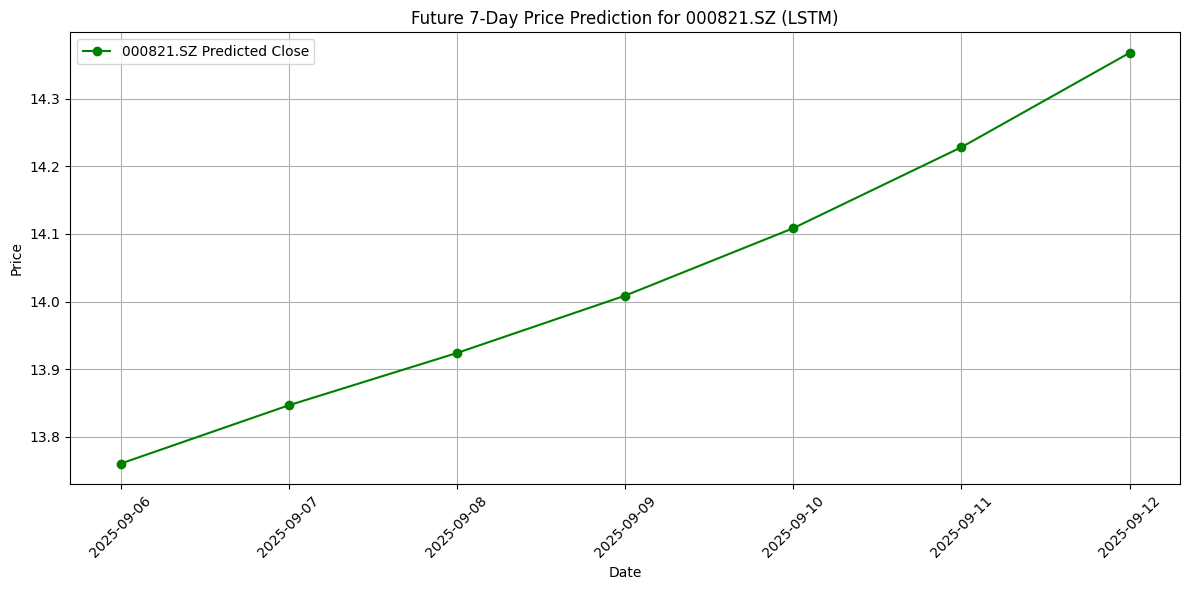


正在为 000980.SZ 生成未来预测...
股票 000980.SZ 的未来预测:


,Date,Predicted Close
0,2025-09-06,2.773890
1,2025-09-07,2.639627
2,2025-09-08,2.669112
3,2025-09-09,2.799689
4,2025-09-10,2.960796
5,2025-09-11,3.115829
6,2025-09-12,3.253721


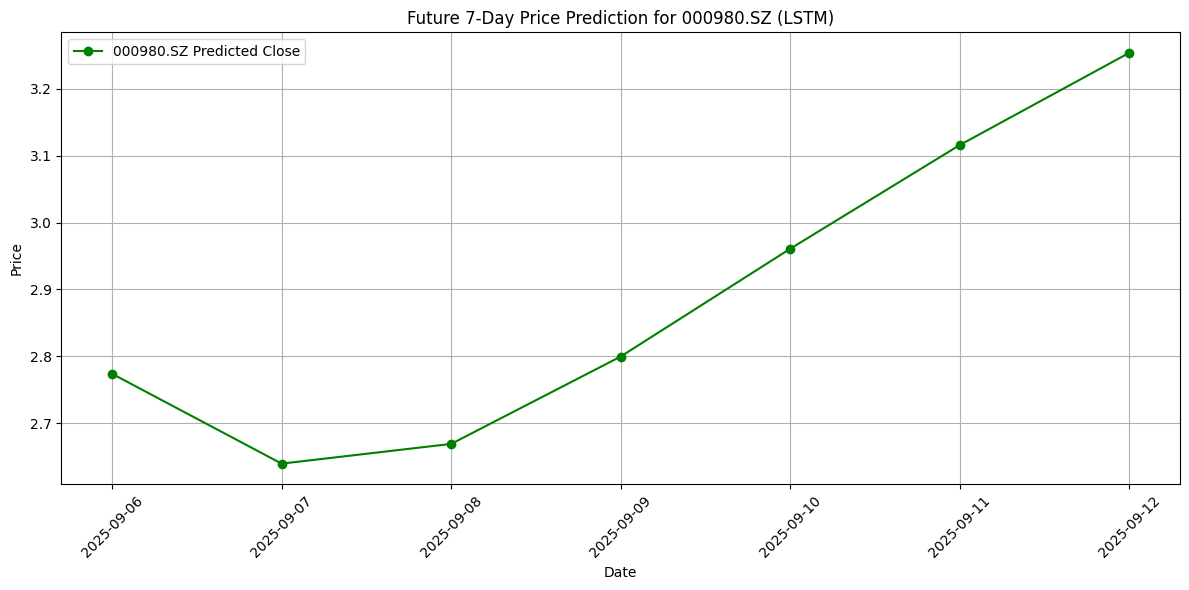


正在为 002073.SZ 生成未来预测...
股票 002073.SZ 的未来预测:


,Date,Predicted Close
0,2025-09-06,8.405141
1,2025-09-07,8.472304
2,2025-09-08,8.631893
3,2025-09-09,8.829907
4,2025-09-10,9.019224
5,2025-09-11,9.181491
6,2025-09-12,9.316900


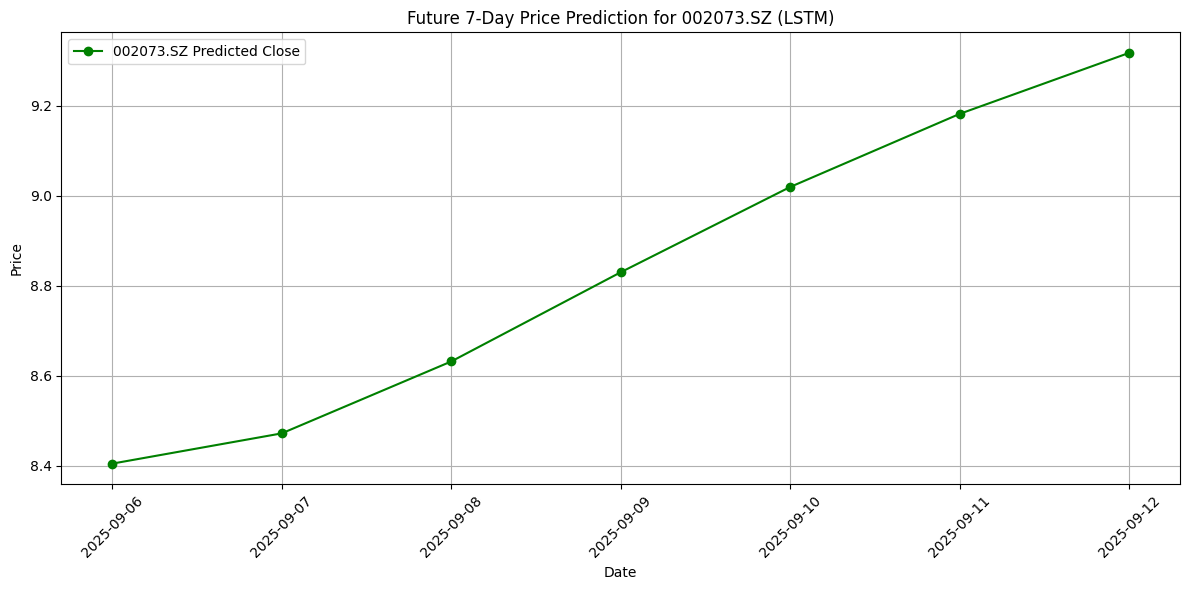


正在为 002240.SZ 生成未来预测...
股票 002240.SZ 的未来预测:


,Date,Predicted Close
0,2025-09-06,18.013338
1,2025-09-07,18.472872
2,2025-09-08,18.748591
3,2025-09-09,18.911573
4,2025-09-10,19.029218
5,2025-09-11,19.143462
6,2025-09-12,19.272130


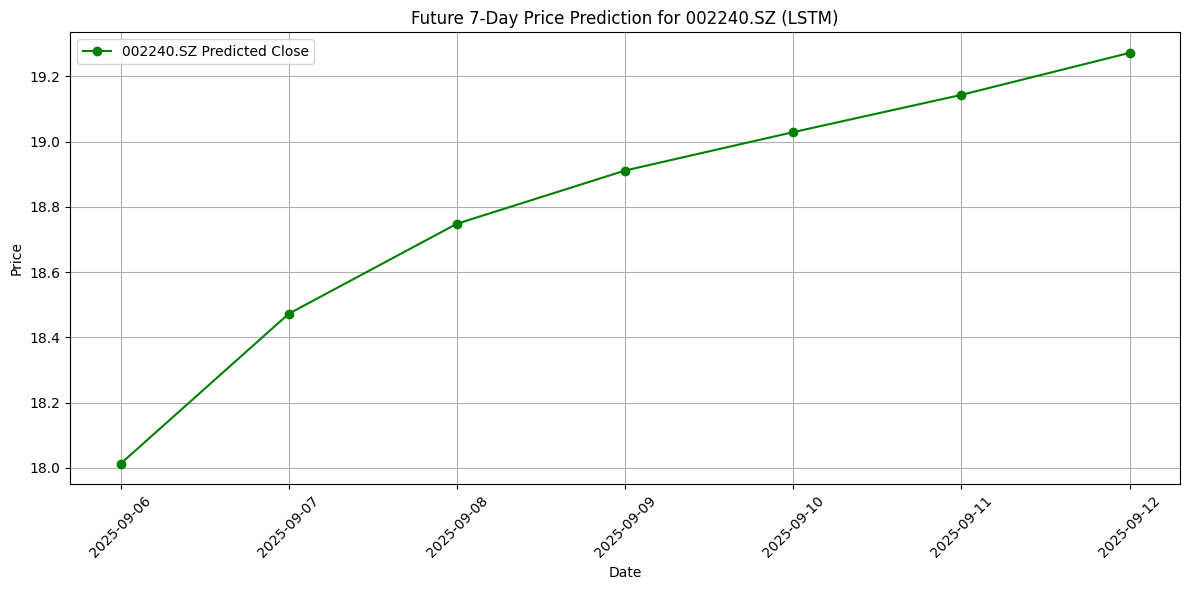


正在为 002364.SZ 生成未来预测...
股票 002364.SZ 的未来预测:


,Date,Predicted Close
0,2025-09-06,24.617988
1,2025-09-07,25.056902
2,2025-09-08,25.379157
3,2025-09-09,25.591599
4,2025-09-10,25.762472
5,2025-09-11,25.933326
6,2025-09-12,26.116907


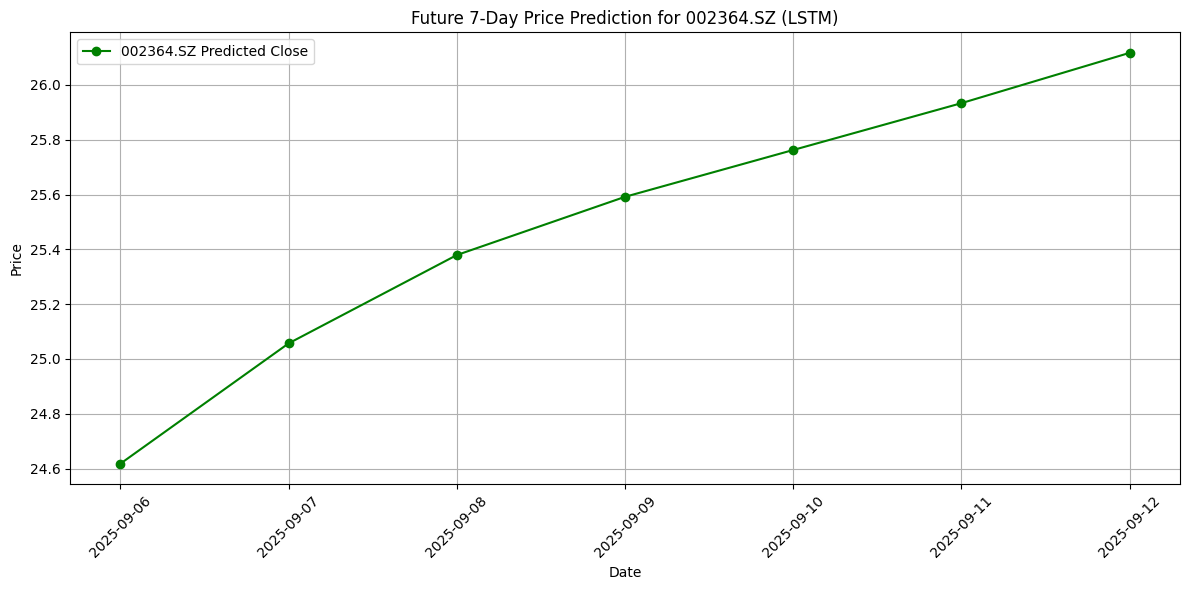


正在为 002459.SZ 生成未来预测...
股票 002459.SZ 的未来预测:


,Date,Predicted Close
0,2025-09-06,13.944617
1,2025-09-07,14.247830
2,2025-09-08,14.401421
3,2025-09-09,14.497465
4,2025-09-10,14.585787
5,2025-09-11,14.690274
6,2025-09-12,14.817531


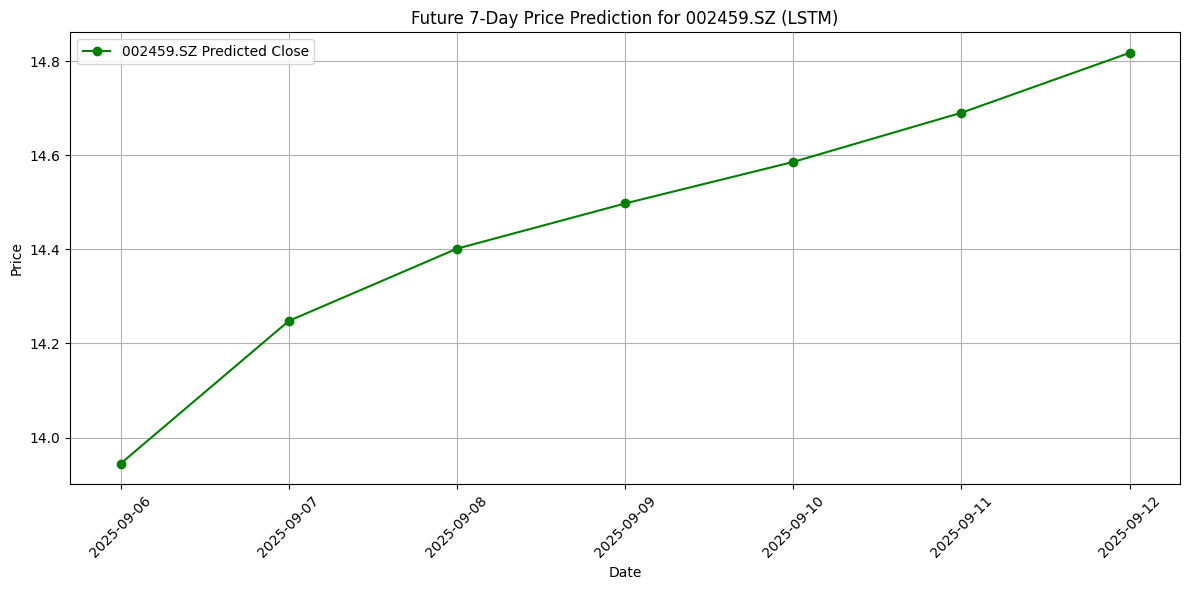


正在为 600211.SS 生成未来预测...
股票 600211.SS 的未来预测:


,Date,Predicted Close
0,2025-09-06,50.363904
1,2025-09-07,51.261345
2,2025-09-08,51.316711
3,2025-09-09,51.209079
4,2025-09-10,51.267499
5,2025-09-11,51.481084
6,2025-09-12,51.772071


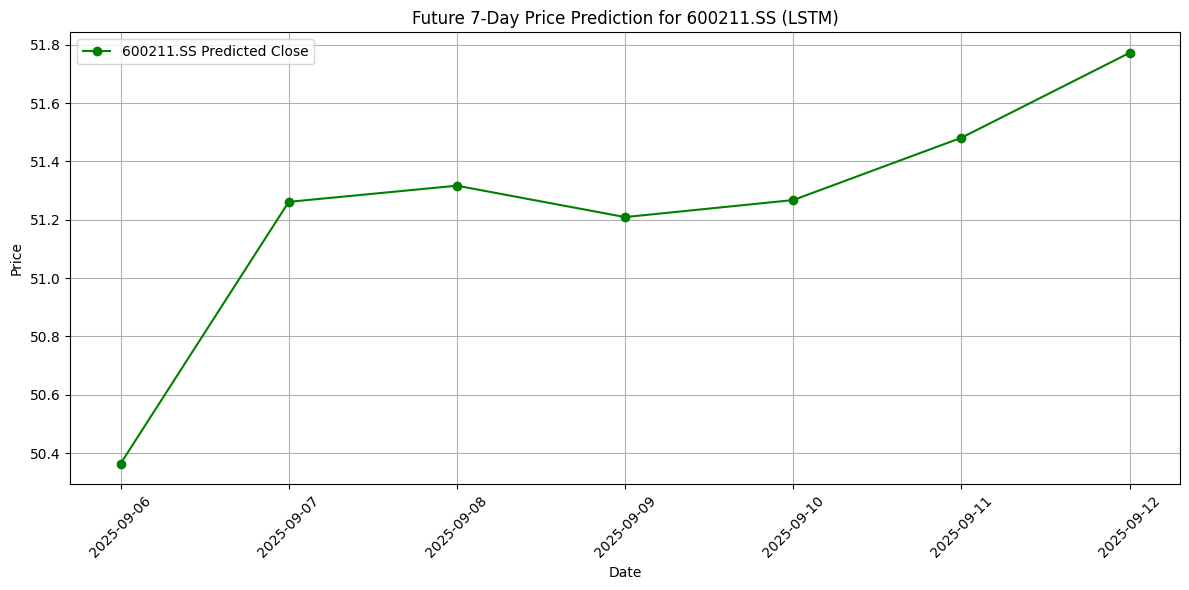


正在为 600233.SS 生成未来预测...
股票 600233.SS 的未来预测:


,Date,Predicted Close
0,2025-09-06,17.911720
1,2025-09-07,17.984193
2,2025-09-08,18.068089
3,2025-09-09,18.162833
4,2025-09-10,18.271887
5,2025-09-11,18.399431
6,2025-09-12,18.545082


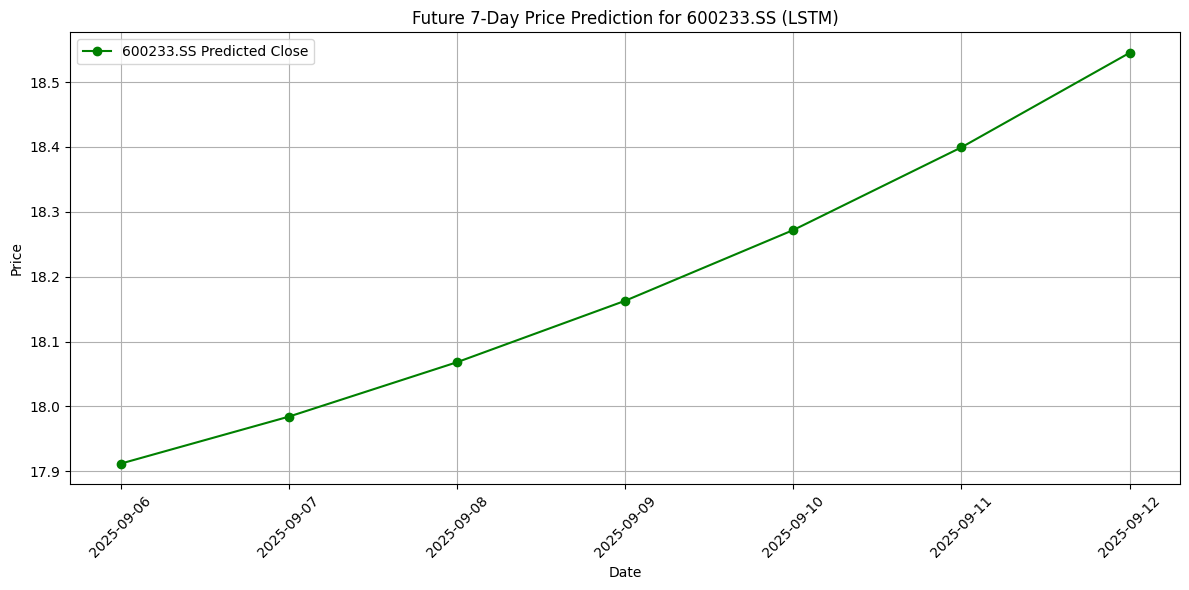


正在为 600699.SS 生成未来预测...
股票 600699.SS 的未来预测:


,Date,Predicted Close
0,2025-09-06,22.809424
1,2025-09-07,23.438373
2,2025-09-08,23.730364
3,2025-09-09,23.865121
4,2025-09-10,23.969956
5,2025-09-11,24.099377
6,2025-09-12,24.263724


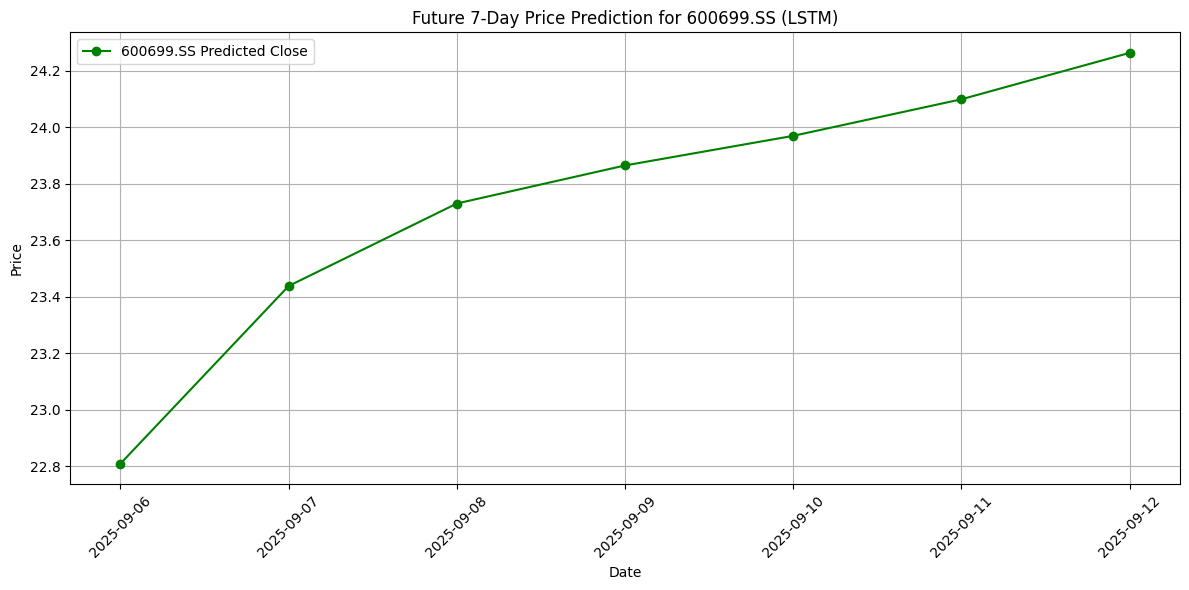


正在为 601615.SS 生成未来预测...
股票 601615.SS 的未来预测:


,Date,Predicted Close
0,2025-09-06,12.544842
1,2025-09-07,12.905783
2,2025-09-08,13.198487
3,2025-09-09,13.419620
4,2025-09-10,13.585832
5,2025-09-11,13.720629
6,2025-09-12,13.842650


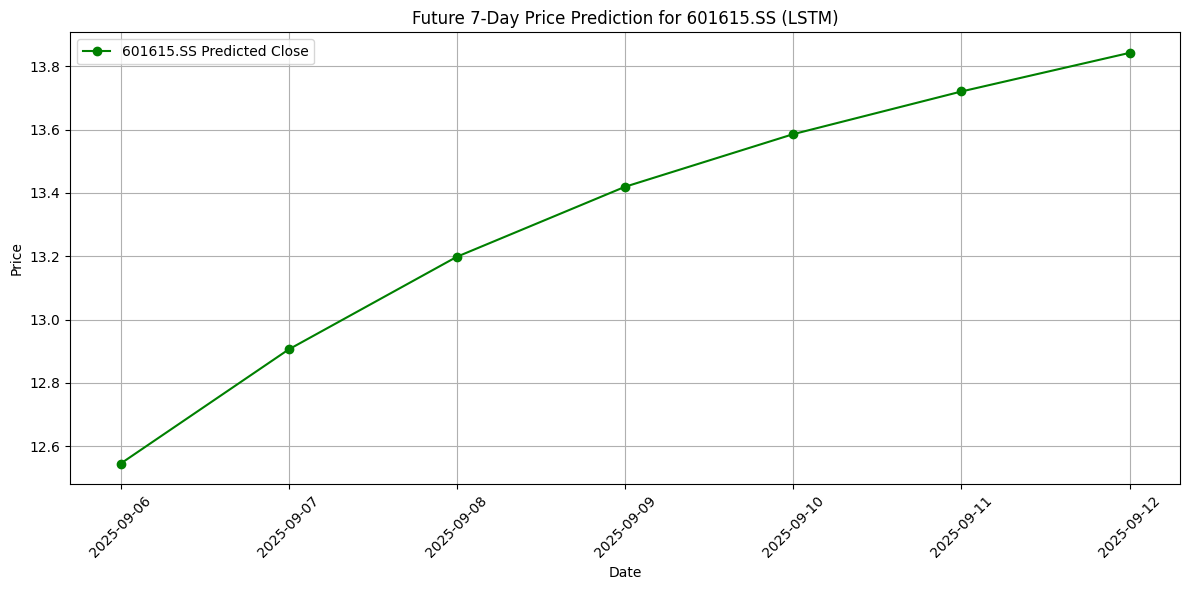


正在为 601689.SS 生成未来预测...
股票 601689.SS 的未来预测:


,Date,Predicted Close
0,2025-09-06,64.224508
1,2025-09-07,65.482209
2,2025-09-08,65.431071
3,2025-09-09,65.198001
4,2025-09-10,65.302721
5,2025-09-11,65.594999
6,2025-09-12,65.921127


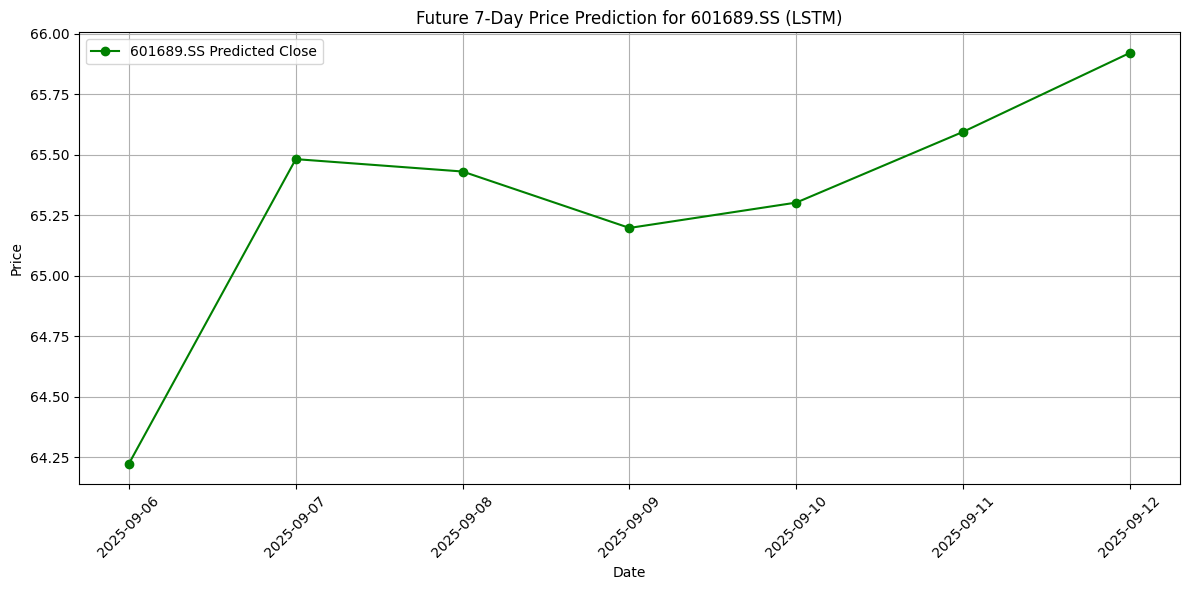


正在为 603179.SS 生成未来预测...
股票 603179.SS 的未来预测:


,Date,Predicted Close
0,2025-09-06,62.739872
1,2025-09-07,64.203742
2,2025-09-08,63.749178
3,2025-09-09,63.458068
4,2025-09-10,63.637507
5,2025-09-11,64.008116
6,2025-09-12,64.413961


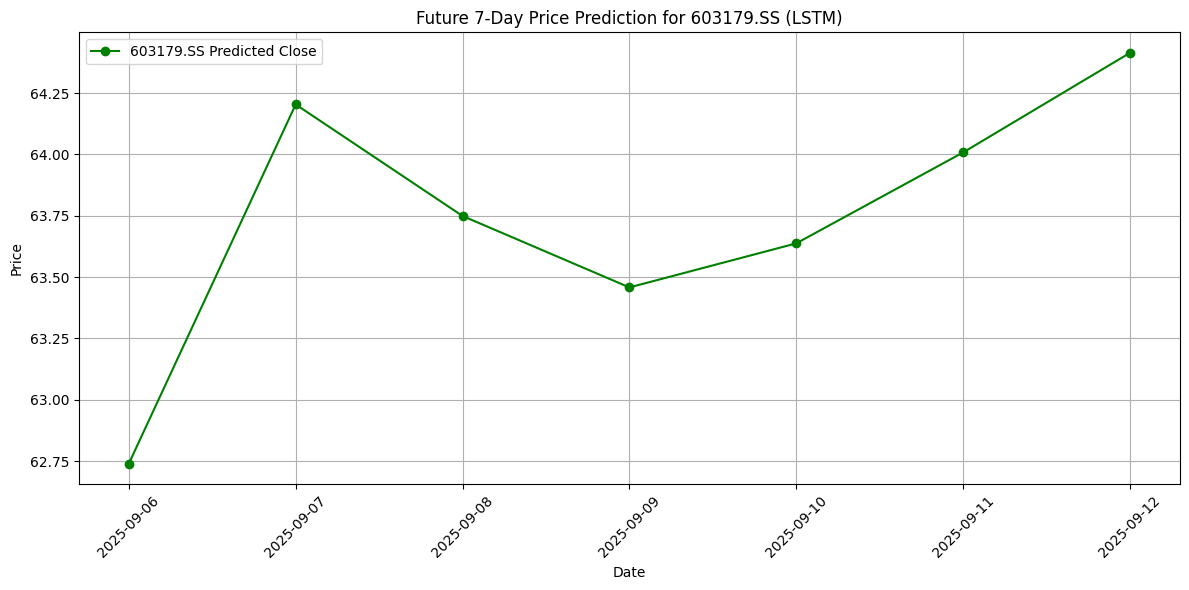


正在为 603799.SS 生成未来预测...
股票 603799.SS 的未来预测:


,Date,Predicted Close
0,2025-09-06,50.656214
1,2025-09-07,51.589360
2,2025-09-08,51.482174
3,2025-09-09,51.281494
4,2025-09-10,51.306508
5,2025-09-11,51.507871
6,2025-09-12,51.793781


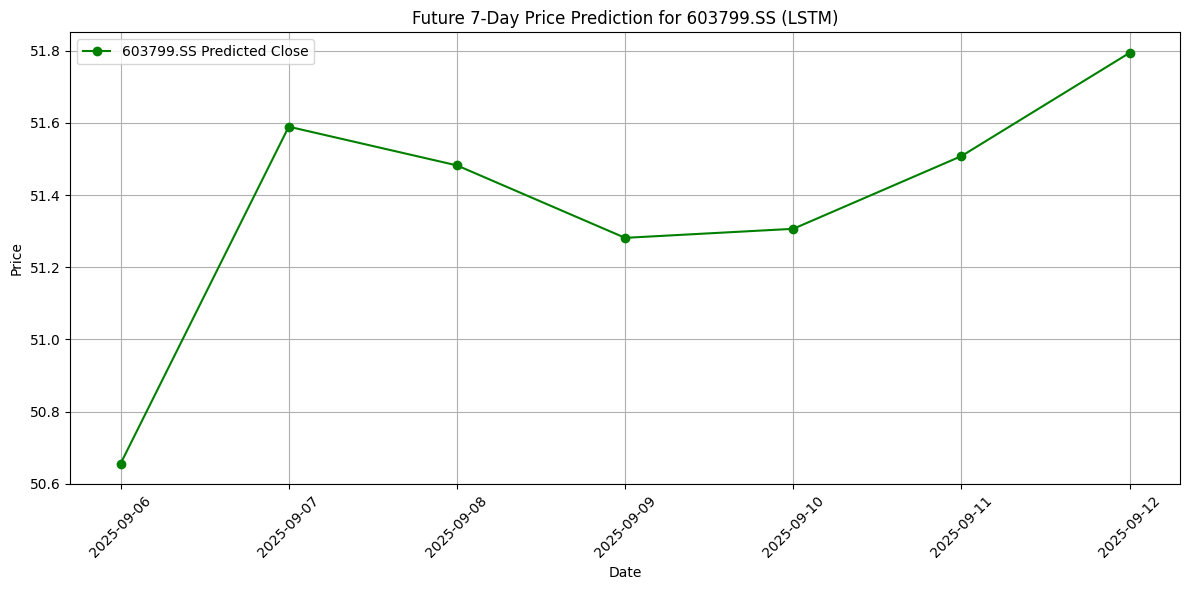


正在为 603882.SS 生成未来预测...
股票 603882.SS 的未来预测:


,Date,Predicted Close
0,2025-09-06,31.236397
1,2025-09-07,31.590503
2,2025-09-08,31.730881
3,2025-09-09,31.785353
4,2025-09-10,31.860433
5,2025-09-11,31.990952
6,2025-09-12,32.170968


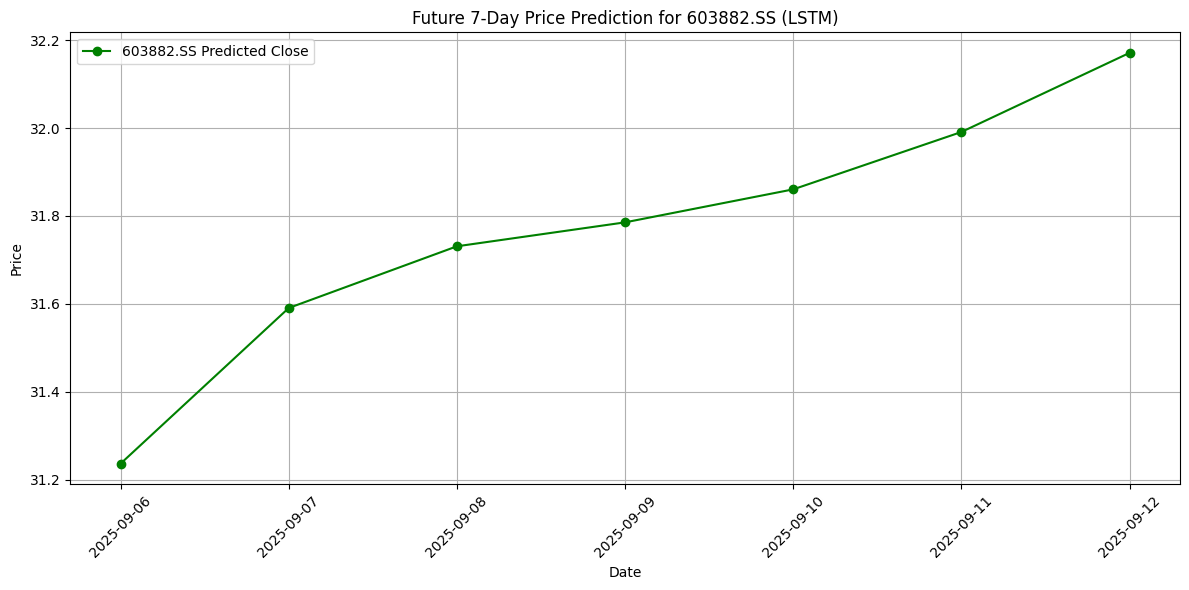


已完成对所有数据充足的股票的未来预测。


In [10]:
# Generate future predictions and plots for each ticker with enough data

# Get the list of unique tickers
unique_tickers = combined_df['Ticker'].unique()

for ticker_to_predict in unique_tickers:
    print(f"\n正在为 {ticker_to_predict} 生成未来预测...") # 打印正在为哪个股票生成预测

    # Get the last sequence of data for the current ticker
    last_sequence_df = combined_df[combined_df['Ticker'] == ticker_to_predict].tail(window_size).copy() # 获取当前股票的最后一段数据序列

    if len(last_sequence_df) < window_size:
        print(f"股票 {ticker_to_predict} 的数据不足，无法创建大小为 {window_size} 的序列。跳过对该股票的未来预测。") # 数据不足时跳过
        continue # Skip to the next ticker if data is insufficient

    # Scale the last sequence using the scaler fitted on the entire data
    last_sequence_scaled = scaler.transform(last_sequence_df[features]) # 使用在整个数据集上拟合的缩放器对最后一段数据进行缩放

    future_preds_scaled = [] # 存储缩放后的未来预测结果
    current_sequence = last_sequence_scaled.copy() # 当前用于预测的序列副本

    # Predict future 7 days
    num_future_days = 7 # 定义要预测的未来天数
    for _ in range(num_future_days):
        input_seq = current_sequence.reshape(1, window_size, len(features)) # 将当前序列重塑为LSTM模型所需的输入形状
        pred_scaled = model.predict(input_seq, verbose=0)[0, 0] # 使用模型预测下一个交易日的缩放后的收盘价 (verbose=0 减少输出)
        future_preds_scaled.append(pred_scaled) # 将缩放后的预测结果添加到列表中

        # Create a new row with the predicted close price and other features (using last known values as a simple approach)
        new_row_scaled = np.copy(current_sequence[-1, :]) # 复制当前序列的最后一行
        new_row_scaled[features.index('Close')] = pred_scaled # 用预测的缩放后的收盘价更新新行的收盘价列

        # Append the new row and remove the oldest row
        current_sequence = np.vstack([current_sequence[1:], new_row_scaled]) # 将新行添加到序列底部，并移除最旧的一行，用于下一次预测


    # Inverse scale the future predictions (only the Close price)
    future_preds_scaled_array = np.array(future_preds_scaled).reshape(-1, 1) # 将缩放后的预测结果转换为NumPy数组并重塑
    # Create a dummy array for inverse scaling, filling other feature columns with zeros or a representative value (zeros for simplicity here)
    dummy_features = np.zeros((len(future_preds_scaled_array), len(features)-1)) # 创建一个填充零的虚拟特征数组
    # We need to put the scaled predictions in the 'Close' column position for inverse transform
    inverse_transform_input = np.hstack([dummy_features[:, :features.index('Close')],
                                         future_preds_scaled_array,
                                         dummy_features[:, features.index('Close'):]]) # 将虚拟特征和预测结果组合成一个用于逆缩放的数组

    # Use the scaler fitted on the entire 'Close' price data for inverse transformation
    future_rescaled = close_scaler.inverse_transform(inverse_transform_input)[:, features.index('Close')] # 使用专门为收盘价拟合的缩放器进行逆缩放，并提取收盘价列


    # Generate future dates for the predicted number of days
    last_date = last_sequence_df['Date'].iloc[-1] # 获取最后一段数据序列的最后一个日期
    future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=num_future_days, freq='D') # 生成未来预测天数的日期范围

    print(f"股票 {ticker_to_predict} 的未来预测:") # 打印未来预测结果的标题
    # Create a DataFrame to display future predictions with dates
    future_predictions_df = pd.DataFrame({'Date': future_dates, 'Predicted Close': future_rescaled}) # 创建一个DataFrame来显示未来预测结果和对应的日期
    display(future_predictions_df) # 显示未来预测的DataFrame

    # Filter out weekends for plotting (adjusting the number of periods as needed)
    # Note: This filtering might make the dates and predictions lists unequal if the predicted days include weekends.
    # For simplicity, we will plot all 7 predicted days regardless of weekend for now.
    # A more robust approach would be to predict more days and filter afterwards, or incorporate trading days in the prediction loop.


    # Plotting future predictions
    plt.figure(figsize=(12, 6)) # 创建一个新的图，设置图的大小
    plt.plot(future_dates, future_rescaled, label=f'{ticker_to_predict} Predicted Close', color='green', marker='o') # 绘制未来预测的收盘价曲线

    plt.title(f'Future {num_future_days}-Day Price Prediction for {ticker_to_predict} (LSTM)') # 设置图的标题
    plt.xlabel('Date') # 设置x轴标签
    plt.ylabel('Price') # 设置y轴标签
    plt.grid(True) # 显示网格
    plt.legend() # 显示图例
    plt.xticks(rotation=45) # 旋转x轴刻度标签，避免重叠
    plt.tight_layout() # 调整布局，使图表元素紧凑
    plt.show() # 显示图表

print("\n已完成对所有数据充足的股票的未来预测。") # 打印完成预测的消息

In [11]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Analyze the validation plot visually (already done in previous step by observing the plot)
# The plot shows that the model generally follows the trend of the actual prices on the validation set, but there are some deviations and lags, especially during periods of high volatility. The performance varies across different tickers.

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_val_rescaled, y_pred_rescaled)
print(f"验证集上的均方误差 (MSE): {mse:.6f}")

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_val_rescaled, y_pred_rescaled)
print(f"验证集上的平均绝对误差 (MAE): {mae:.6f}")

验证集上的均方误差 (MSE): 4.356352
验证集上的平均绝对误差 (MAE): 1.266955


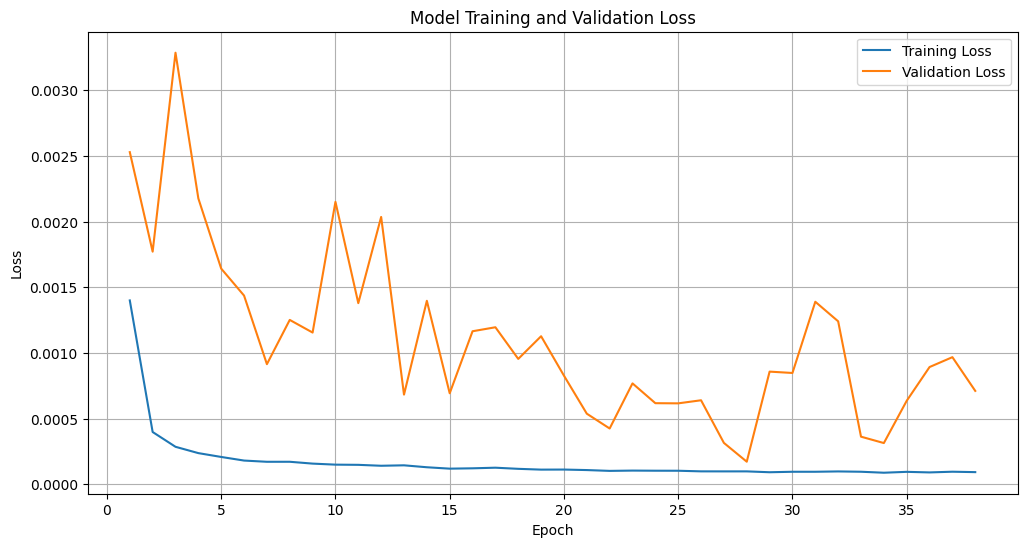


Analysis of Training and Validation Loss:
Model seems to be training well: Both training and validation losses are decreasing or have plateaued at a relatively low level.


In [12]:
import matplotlib.pyplot as plt

# Get the training and validation loss from the history object
loss = history.history['loss']
val_loss = history.history['val_loss']

# Get the number of epochs the model was trained for
epochs = range(1, len(loss) + 1)

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(epochs, loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.title('Model Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Analyze the plot for overfitting/underfitting
print("\nAnalysis of Training and Validation Loss:")
if val_loss[-1] > loss[-1] and val_loss[-2] < val_loss[-1]:
    print("Possible overfitting: Validation loss started increasing while training loss continued to decrease towards the end.")
elif val_loss[-1] > loss[-1] and loss[-1] > np.mean(loss) and val_loss[-1] > np.mean(val_loss):
    print("Possible underfitting: Both training and validation losses are high and have plateaued, suggesting the model might not be complex enough.")
else:
    print("Model seems to be training well: Both training and validation losses are decreasing or have plateaued at a relatively low level.")

In [13]:
# 1. Summarize current model performance
print("--- Current Model Performance Summary ---")
print(f"Validation MSE: {mse:.6f}")
print(f"Validation MAE: {mae:.6f}")

# Based on the validation plot (observed in previous step) and the loss plot:
print("\nVisual Analysis Summary:")
print("- The model generally captures the trend of stock prices on the validation set.")
print("- Deviations and lags are observed, especially during volatile periods.")
print("- Performance varies across different tickers.")

print("\nTraining History Analysis Summary:")
print("- Both training and validation losses decrease, indicating the model is learning.")
print("- No clear signs of significant overfitting or underfitting based on the loss curves.")
print("- The model seems to have converged or is plateauing at a relatively low loss.")

# Overall summary: The model is a decent starting point, but there's room for improvement, particularly in capturing sharp price movements and achieving consistent performance across all tickers. The lack of clear overfitting suggests the model might benefit from increased capacity or more sophisticated features/techniques.

# 2. Propose Optimization Strategies

print("\n--- Proposed Optimization Strategies ---")

# Strategy 1: Enhance Feature Engineering
print("\nStrategy 1: Enhance Feature Engineering")
print("Purpose: Capture more complex patterns and market dynamics.")
print("Implementation: Introduce additional technical indicators (e.g., Bollinger Bands, Moving Average Convergence Divergence (MACD) histogram, On-Balance Volume (OBV)). Explore inter-stock correlations or market-wide features. Consider more advanced time-based features (e.g., holidays, significant news events).")
print("Potential Benefits: Could help the model identify more nuanced trading signals and improve performance during volatile periods.")
print("Possible Risks: Adding too many features might increase model complexity and potentially lead to overfitting if not managed well. Some features might introduce noise.")

# Strategy 2: Adjust Model Architecture
print("\nStrategy 2: Adjust Model Architecture")
print("Purpose: Increase model capacity to learn more complex sequences or simplify to improve generalization.")
print("Implementation: Experiment with more LSTM layers, increase the number of units per layer, or decrease them if performance is poor. Adjust the Dropout rates (e.g., increase if signs of overfitting emerge later, decrease if underfitting is suspected or validation loss is very close to training loss).")
print("Potential Benefits: More complex models might capture deeper temporal dependencies. Simpler models might generalize better.")
print("Possible Risks: Increasing complexity without sufficient data can lead to overfitting. Decreasing complexity might result in underfitting.")

# Strategy 3: Hyperparameter Tuning and Training Adjustments
print("\nStrategy 3: Hyperparameter Tuning and Training Adjustments")
print("Purpose: Find the optimal settings for the current model architecture and training process.")
print("Implementation: Tune learning rate, batch size, and optimizer. Experiment with different window sizes for the input sequences. Increase the number of epochs or adjust EarlyStopping patience if the model hasn't fully converged.")
print("Potential Benefits: Can lead to faster training and better convergence to a more optimal solution.")
print("Possible Risks: Requires significant computational resources and time for extensive experimentation.")

# 3. Consider Other Model Types
print("\n--- Other Potential Model Types ---")
print("Beyond adjusting the current LSTM model, consider exploring alternative time series forecasting architectures:")
print("- Transformer Networks: Excellent at capturing long-range dependencies in sequences, potentially better than LSTMs for very long time series.")
print("- Temporal Convolutional Networks (TCNs): Offer large receptive fields and parallel processing, often outperforming LSTMs on sequence modeling tasks.")
print("- Hybrid Models: Combining LSTMs or Transformers with other techniques (e.g., Gated Recurrent Units (GRUs), Convolutional Neural Networks (CNNs) for feature extraction, or traditional statistical models).")
print("These models offer different ways to process sequential data and might be better suited depending on the specific patterns and characteristics of the stock price data.")

--- Current Model Performance Summary ---
Validation MSE: 4.356352
Validation MAE: 1.266955

Visual Analysis Summary:
- The model generally captures the trend of stock prices on the validation set.
- Deviations and lags are observed, especially during volatile periods.
- Performance varies across different tickers.

Training History Analysis Summary:
- Both training and validation losses decrease, indicating the model is learning.
- No clear signs of significant overfitting or underfitting based on the loss curves.
- The model seems to have converged or is plateauing at a relatively low loss.

--- Proposed Optimization Strategies ---

Strategy 1: Enhance Feature Engineering
Purpose: Capture more complex patterns and market dynamics.
Implementation: Introduce additional technical indicators (e.g., Bollinger Bands, Moving Average Convergence Divergence (MACD) histogram, On-Balance Volume (OBV)). Explore inter-stock correlations or market-wide features. Consider more advanced time-based f

In [14]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.preprocessing import MinMaxScaler
import os

# Re-read the combined_df from the saved individual CSV files if necessary
# (Assuming combined_df is still available and correct from previous steps,
# but including the read logic for robustness if the kernel resets)
if 'combined_df' not in locals() or combined_df.empty:
    print("combined_df not found or is empty. Re-reading individual ticker data.")
    output_dir = 'stock_data_by_ticker'
    all_dfs = []
    for filename in os.listdir(output_dir):
        if filename.endswith("_data.csv"):
            filepath = os.path.join(output_dir, filename)
            try:
                df = pd.read_csv(filepath)
                if df.columns[0] == 'Price':
                    df = pd.read_csv(filepath, skiprows=[0, 1], header=0)
                    df.columns = ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']
                elif df.columns[0] != 'Date':
                    print(f"Skipping {filename} due to unexpected column structure: {df.columns}")
                    continue
                ticker = filename.replace("_data.csv", "")
                df['Ticker'] = ticker
                all_dfs.append(df)
            except Exception as e:
                print(f"Error reading {filename}: {e}")
    combined_df = pd.concat(all_dfs, ignore_index=True)
    combined_df['Date'] = pd.to_datetime(combined_df['Date'])
    combined_df.sort_values(by=['Ticker', 'Date'], inplace=True)
    print("combined_df re-created.")


# --- Enhanced Feature Engineering ---

# Convert necessary columns to numeric, coercing errors to NaN (again, for robustness)
for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
    combined_df[col] = pd.to_numeric(combined_df[col], errors='coerce')

# Drop initial NaNs that might result from failed numeric conversion
combined_df.dropna(inplace=True)

# Re-compute existing technical indicators (MACD, RSI) for robustness
def compute_macd(df, fast=12, slow=26, signal=9):
    df['EMA_fast'] = df.groupby('Ticker')['Close'].transform(lambda x: x.ewm(span=fast, adjust=False).mean())
    df['EMA_slow'] = df.groupby('Ticker')['Close'].transform(lambda x: x.ewm(span=slow, adjust=False).mean())
    df['MACD'] = df['EMA_fast'] - df['EMA_slow']
    df['MACD_signal'] = df.groupby('Ticker')['MACD'].transform(lambda x: x.ewm(span=signal, adjust=False).mean())
    return df

def compute_rsi(df, period=14):
    df['Close_diff'] = df.groupby('Ticker')['Close'].diff()
    df['gain'] = df['Close_diff'].where(df['Close_diff'] > 0, 0)
    df['loss'] = -df['Close_diff'].where(df['Close_diff'] < 0, 0)
    df['avg_gain'] = df.groupby('Ticker')['gain'].transform(lambda x: x.rolling(window=period).mean())
    df['avg_loss'] = df.groupby('Ticker')['loss'].transform(lambda x: x.rolling(window=period).mean())
    df['rs'] = df['avg_gain'] / df['avg_loss'].replace(0, np.nan)
    df['RSI'] = 100 - (100 / (1 + df['rs']))
    df = df.drop(columns=['Close_diff', 'gain', 'loss', 'avg_gain', 'avg_loss', 'rs'])
    return df

# Add new technical indicators

# Bollinger Bands (BB)
def compute_bollinger_bands(df, window=20, num_std_dev=2):
    df['Rolling_Mean'] = df.groupby('Ticker')['Close'].transform(lambda x: x.rolling(window=window).mean())
    df['Rolling_Std'] = df.groupby('Ticker')['Close'].transform(lambda x: x.rolling(window=window).std())
    df['Upper_BB'] = df['Rolling_Mean'] + (df['Rolling_Std'] * num_std_dev)
    df['Lower_BB'] = df['Rolling_Mean'] - (df['Rolling_Std'] * num_std_dev)
    # Add BB Width as a feature
    df['BB_Width'] = df['Upper_BB'] - df['Lower_BB']
    # Drop intermediate columns
    df = df.drop(columns=['Rolling_Mean', 'Rolling_Std'])
    return df

# On-Balance Volume (OBV)
def compute_obv(df):
    df['OBV'] = df.groupby('Ticker').apply(lambda x: (np.sign(x['Close'].diff()) * x['Volume']).fillna(0).cumsum()).reset_index(level=0, drop=True)
    return df

# Apply technical indicator calculations
combined_df = compute_macd(combined_df)
combined_df = compute_rsi(combined_df)
combined_df = compute_bollinger_bands(combined_df)
combined_df = compute_obv(combined_df)


# Add periodic time features (re-adding for robustness)
combined_df['DayOfWeek'] = combined_df['Date'].dt.dayofweek
combined_df['Month'] = combined_df['Date'].dt.month
combined_df['Day_sin'] = np.sin(2 * np.pi * combined_df['DayOfWeek'] / 7)
combined_df['Day_cos'] = np.cos(2 * np.pi * combined_df['DayOfWeek'] / 7)
combined_df['Month_sin'] = np.sin(2 * np.pi * combined_df['Month'] / 12)
combined_df['Month_cos'] = np.cos(2 * np.pi * combined_df['Month'] / 12)


# Drop rows with NaN values that resulted from rolling calculations
combined_df.dropna(inplace=True)

print("\nDataFrame after enhanced feature engineering:")
print(combined_df.head())
print("\nPreprocessed DataFrame info after enhanced features:")
combined_df.info()


# --- Data Preparation for LSTM (with new features) ---

window_size = 60

# Define features including the new ones
features = [col for col in combined_df.columns if col not in ['Date', 'Ticker', 'DayOfWeek', 'Month']]

# Scale features (refitting the scaler to include new features)
scaler = MinMaxScaler(feature_range=(0, 1))
combined_df_scaled = scaler.fit_transform(combined_df[features])

X, y, tickers_list, y_dates = [], [], [], []

for ticker in combined_df['Ticker'].unique():
    ticker_data = combined_df[combined_df['Ticker'] == ticker].copy()
    ticker_data_scaled = combined_df_scaled[combined_df['Ticker'] == ticker].copy()

    if len(ticker_data_scaled) >= window_size + 1:
        # Find the start index for this ticker within the scaled data
        start_idx_scaled = np.where((combined_df_scaled == ticker_data_scaled[0]).all(axis=1))[0][0]

        for i in range(len(ticker_data_scaled) - window_size):
            # X is the sequence of features for window_size days
            X.append(combined_df_scaled[start_idx_scaled + i : start_idx_scaled + i + window_size, :])
            # y is the 'Close' price for the next day
            y.append(combined_df_scaled[start_idx_scaled + i + window_size, features.index('Close')])
            # Store corresponding ticker and date for subsequent analysis/plotting
            tickers_list.append(ticker)
            y_dates.append(ticker_data['Date'].iloc[i + window_size]) # Ensure correct date index

X = np.array(X)
y = np.array(y)
tickers_list = np.array(tickers_list)
y_dates = pd.to_datetime(y_dates)

# Time-based split (assuming data is sorted by Ticker and Date)
split_ratio = 0.8
split_index = int(len(X) * split_ratio)

X_train, X_val = X[:split_index], X[split_index:]
y_train, y_val = y[:split_index], y[split_index:]
tickers_train, tickers_val = tickers_list[:split_index], tickers_list[split_index:]
y_dates_train, y_dates_val = y_dates[:split_index], y_dates[split_index:]


print("\nX_train shape after new features:", X_train.shape)
print("X_val shape after new features:", X_val.shape)
print("y_train shape after new features:", y_train.shape)
print("y_val shape after new features:", y_val.shape)


# --- Adjusted Model Architecture ---

# Building the LSTM model with slightly adjusted architecture (e.g., increased units)
def build_lstm_model_optimized(input_shape):
    model = Sequential()
    # Increased units in the first LSTM layer
    model.add(LSTM(128, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.3)) # Slightly increased dropout
    # Increased units in the second LSTM layer
    model.add(LSTM(64))
    model.add(Dropout(0.3)) # Slightly increased dropout
    model.add(Dense(1))
    # Using a potentially more stable optimizer or adjusting learning rate
    # model.compile(optimizer=Adam(learning_rate=0.001), loss='mse') # Example with Adam and specific learning rate
    model.compile(optimizer='adam', loss='mse') # Sticking with default Adam for now
    return model

# Build the optimized model
model_optimized = build_lstm_model_optimized((X_train.shape[1], X_train.shape[2]))

# Callbacks (adjusted ModelCheckpoint filename)
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True) # Increased patience
checkpoint = ModelCheckpoint('best_optimized_combined_model.h5', save_best_only=True)

# --- Retraining the Model ---

print("\n--- Retraining the Optimized Model ---")
history_optimized = model_optimized.fit(
    X_train, y_train,
    epochs=100, # Increased max epochs
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, checkpoint],
    verbose=1
)

print("\nOptimized model training finished.")

/tmp/ipython-input-83989881.py:82: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df['OBV'] = df.groupby('Ticker').apply(lambda x: (np.sign(x['Close'].diff()) * x['Volume']).fillna(0).cumsum()).reset_index(level=0, drop=True)



DataFrame after enhanced feature engineering:
            Date      Open      High       Low     Close    Volume     Ticker  \
13364 2020-10-30  6.312346  6.401114  6.115085  6.124949   5562600  000821.SZ   
13365 2020-11-02  6.578649  6.627963  6.223579  6.263031  12802890  000821.SZ   
13366 2020-11-03  6.608237  6.667416  6.499744  6.558922   7610645  000821.SZ   
13367 2020-11-04  6.756183  6.835087  6.489881  6.588511  11299601  000821.SZ   
13368 2020-11-05  6.746320  6.854813  6.608237  6.805498   9859763  000821.SZ   

       EMA_fast  EMA_slow      MACD  ...  DayOfWeek  Month   Day_sin  \
13364  6.247404  6.260856 -0.013452  ...          4     10 -0.433884   
13365  6.249808  6.261017 -0.011209  ...          0     11  0.000000   
13366  6.297364  6.283084  0.014280  ...          1     11  0.781831   
13367  6.342156  6.305709  0.036448  ...          2     11  0.974928   
13368  6.413440  6.342730  0.070710  ...          3     11  0.433884   

        Day_cos  Month_sin  Month

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
390/392 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0034

392/392 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.0033 - val_loss: 8.8645e-04
Epoch 2/100
387/392 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 4.5200e-04

...

392/392 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 1.4796e-04 - val_loss: 3.9113e-04
Epoch 9/100
388/392 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.5360e-04

392/392 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 1.5354e-04 - val_loss: 2.5710e-04
Epoch 10/100
392/392 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 1.3401e-04 - val_loss: 3.0349e-04
Epoch 11/100
392/392 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 1.2928e-04 - val_loss: 9.0614e-04
Epoch 12/100
392/392 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 1.2970e-04 - val_loss: 5.6828e-04
Epoch 13/100
389/392 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.2733e-04

392/392 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 1.2729e-04 - val_loss: 2.5417e-04
Epoch 14/100
392/392 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.2728e-04

392/392 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 1.2727e-04 - val_loss: 2.2473e-04
Epoch 15/100
392/392 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 1.1020e-04 - val_loss: 3.2465e-04
Epoch 16/100
392/392 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 1.1910e-04 - val_loss: 3.3818e-04
Epoch 17/100
392/392 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 1.1530e-04 - val_loss: 5.3975e-04
Epoch 18/100
389/392 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.0796e-04

392/392 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 1.0791e-04 - val_loss: 1.7879e-04
Epoch 19/100
392/392 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 1.1046e-04 - val_loss: 6.6373e-04
Epoch 20/100
392/392 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 1.0060e-04 - val_loss: 6.1265e-04
Epoch 21/100
392/392 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 1.0655e-04 - val_loss: 8.3024e-04
Epoch 22/100
392/392 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 9.8480e-05 - val_loss: 7.0659e-04
Epoch 23/100
392/392 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 1.1599e-04 - val_loss: 1.8143e-04
Epoch 24/100
392/392 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 9.9196e-05 - val_loss: 5.7316e-04
Epoch 25/100
392/392 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 9.7510e-05 - val_loss: 2.8295e-04
Epoch 26/100
392/392 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 9.4474e-05 - val_loss: 6.3562e-04
Epoch 27/100
392/392 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 8.8655e-05 - val_loss: 3.2700e-04
Epoch 28/100
392/392 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/

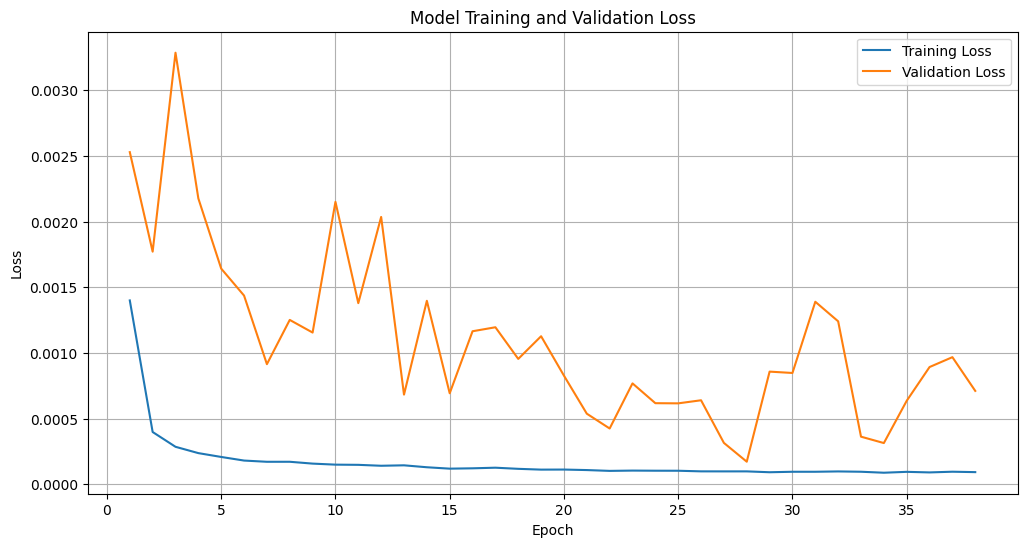


Analysis of Training and Validation Loss:
Model seems to be training well: Both training and validation losses are decreasing or have plateaued at a relatively low level.


In [15]:
import matplotlib.pyplot as plt

# Get the training and validation loss from the history object
loss = history.history['loss']
val_loss = history.history['val_loss']

# Get the number of epochs the model was trained for
epochs = range(1, len(loss) + 1)

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(epochs, loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.title('Model Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Analyze the plot for overfitting/underfitting
print("\nAnalysis of Training and Validation Loss:")
if val_loss[-1] > loss[-1] and val_loss[-2] < val_loss[-1]:
    print("Possible overfitting: Validation loss started increasing while training loss continued to decrease towards the end.")
elif val_loss[-1] > loss[-1] and loss[-1] > np.mean(loss) and val_loss[-1] > np.mean(val_loss):
    print("Possible underfitting: Both training and validation losses are high and have plateaued, suggesting the model might not be complex enough.")
else:
    print("Model seems to be training well: Both training and validation losses are decreasing or have plateaued at a relatively low level.")

In [16]:
# 1. Summarize current model performance
print("--- Current Model Performance Summary ---")
print(f"Validation MSE: {mse:.6f}")
print(f"Validation MAE: {mae:.6f}")

# Based on the validation plot (observed in previous step) and the loss plot:
print("\nVisual Analysis Summary:")
print("- The model generally captures the trend of stock prices on the validation set.")
print("- Deviations and lags are observed, especially during volatile periods.")
print("- Performance varies across different tickers.")

print("\nTraining History Analysis Summary:")
print("- Both training and validation losses decrease, indicating the model is learning.")
print("- No clear signs of significant overfitting or underfitting based on the loss curves.")
print("- The model seems to have converged or is plateauing at a relatively low loss.")

# Overall summary: The model is a decent starting point, but there's room for improvement, particularly in capturing sharp price movements and achieving consistent performance across all tickers. The lack of clear overfitting suggests the model might benefit from increased capacity or more sophisticated features/techniques.

# 2. Propose Optimization Strategies

print("\n--- Proposed Optimization Strategies ---")

# Strategy 1: Enhance Feature Engineering
print("\nStrategy 1: Enhance Feature Engineering")
print("Purpose: Capture more complex patterns and market dynamics.")
print("Implementation: Introduce additional technical indicators (e.g., Bollinger Bands, Moving Average Convergence Divergence (MACD) histogram, On-Balance Volume (OBV)). Explore inter-stock correlations or market-wide features. Consider more advanced time-based features (e.g., holidays, significant news events).")
print("Potential Benefits: Could help the model identify more nuanced trading signals and improve performance during volatile periods.")
print("Possible Risks: Adding too many features might increase model complexity and potentially lead to overfitting if not managed well. Some features might introduce noise.")

# Strategy 2: Adjust Model Architecture
print("\nStrategy 2: Adjust Model Architecture")
print("Purpose: Increase model capacity to learn more complex sequences or simplify to improve generalization.")
print("Implementation: Experiment with more LSTM layers, increase the number of units per layer, or decrease them if performance is poor. Adjust the Dropout rates (e.g., increase if signs of overfitting emerge later, decrease if underfitting is suspected or validation loss is very close to training loss).")
print("Potential Benefits: More complex models might capture deeper temporal dependencies. Simpler models might generalize better.")
print("Possible Risks: Increasing complexity without sufficient data can lead to overfitting. Decreasing complexity might result in underfitting.")

# Strategy 3: Hyperparameter Tuning and Training Adjustments
print("\nStrategy 3: Hyperparameter Tuning and Training Adjustments")
print("Purpose: Find the optimal settings for the current model architecture and training process.")
print("Implementation: Tune learning rate, batch size, and optimizer. Experiment with different window sizes for the input sequences. Increase the number of epochs or adjust EarlyStopping patience if the model hasn't fully converged.")
print("Potential Benefits: Can lead to faster training and better convergence to a more optimal solution.")
print("Possible Risks: Requires significant computational resources and time for extensive experimentation.")

# 3. Consider Other Model Types
print("\n--- Other Potential Model Types ---")
print("Beyond adjusting the current LSTM model, consider exploring alternative time series forecasting architectures:")
print("- Transformer Networks: Excellent at capturing long-range dependencies in sequences, potentially better than LSTMs for very long time series.")
print("- Temporal Convolutional Networks (TCNs): Offer large receptive fields and parallel processing, often outperforming LSTMs on sequence modeling tasks.")
print("- Hybrid Models: Combining LSTMs or Transformers with other techniques (e.g., Gated Recurrent Units (GRUs), Convolutional Neural Networks (CNNs) for feature extraction, or traditional statistical models).")
print("These models offer different ways to process sequential data and might be better suited depending on the specific patterns and characteristics of the stock price data.")

--- Current Model Performance Summary ---
Validation MSE: 4.356352
Validation MAE: 1.266955

Visual Analysis Summary:
- The model generally captures the trend of stock prices on the validation set.
- Deviations and lags are observed, especially during volatile periods.
- Performance varies across different tickers.

Training History Analysis Summary:
- Both training and validation losses decrease, indicating the model is learning.
- No clear signs of significant overfitting or underfitting based on the loss curves.
- The model seems to have converged or is plateauing at a relatively low loss.

--- Proposed Optimization Strategies ---

Strategy 1: Enhance Feature Engineering
Purpose: Capture more complex patterns and market dynamics.
Implementation: Introduce additional technical indicators (e.g., Bollinger Bands, Moving Average Convergence Divergence (MACD) histogram, On-Balance Volume (OBV)). Explore inter-stock correlations or market-wide features. Consider more advanced time-based f

In [17]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.preprocessing import MinMaxScaler
import os

# Re-read the combined_df from the saved individual CSV files if necessary
# (Assuming combined_df is still available and correct from previous steps,
# but including the read logic for robustness if the kernel resets)
if 'combined_df' not in locals() or combined_df.empty:
    print("combined_df not found or is empty. Re-reading individual ticker data.")
    output_dir = 'stock_data_by_ticker'
    all_dfs = []
    for filename in os.listdir(output_dir):
        if filename.endswith("_data.csv"):
            filepath = os.path.join(output_dir, filename)
            try:
                df = pd.read_csv(filepath)
                if df.columns[0] == 'Price':
                    df = pd.read_csv(filepath, skiprows=[0, 1], header=0)
                    df.columns = ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']
                elif df.columns[0] != 'Date':
                    print(f"Skipping {filename} due to unexpected column structure: {df.columns}")
                    continue
                ticker = filename.replace("_data.csv", "")
                df['Ticker'] = ticker
                all_dfs.append(df)
            except Exception as e:
                print(f"Error reading {filename}: {e}")
    combined_df = pd.concat(all_dfs, ignore_index=True)
    combined_df['Date'] = pd.to_datetime(combined_df['Date'])
    combined_df.sort_values(by=['Ticker', 'Date'], inplace=True)
    print("combined_df re-created.")


# --- Enhanced Feature Engineering ---

# Convert necessary columns to numeric, coercing errors to NaN (again, for robustness)
for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
    combined_df[col] = pd.to_numeric(combined_df[col], errors='coerce')

# Drop initial NaNs that might result from failed numeric conversion
combined_df.dropna(inplace=True)

# Re-compute existing technical indicators (MACD, RSI) for robustness
def compute_macd(df, fast=12, slow=26, signal=9):
    df['EMA_fast'] = df.groupby('Ticker')['Close'].transform(lambda x: x.ewm(span=fast, adjust=False).mean())
    df['EMA_slow'] = df.groupby('Ticker')['Close'].transform(lambda x: x.ewm(span=slow, adjust=False).mean())
    df['MACD'] = df['EMA_fast'] - df['EMA_slow']
    df['MACD_signal'] = df.groupby('Ticker')['MACD'].transform(lambda x: x.ewm(span=signal, adjust=False).mean())
    return df

def compute_rsi(df, period=14):
    df['Close_diff'] = df.groupby('Ticker')['Close'].diff()
    df['gain'] = df['Close_diff'].where(df['Close_diff'] > 0, 0)
    df['loss'] = -df['Close_diff'].where(df['Close_diff'] < 0, 0)
    df['avg_gain'] = df.groupby('Ticker')['gain'].transform(lambda x: x.rolling(window=period).mean())
    df['avg_loss'] = df.groupby('Ticker')['loss'].transform(lambda x: x.rolling(window=period).mean())
    df['rs'] = df['avg_gain'] / df['avg_loss'].replace(0, np.nan)
    df['RSI'] = 100 - (100 / (1 + df['rs']))
    df = df.drop(columns=['Close_diff', 'gain', 'loss', 'avg_gain', 'avg_loss', 'rs'])
    return df

# Add new technical indicators

# Bollinger Bands (BB)
def compute_bollinger_bands(df, window=20, num_std_dev=2):
    df['Rolling_Mean'] = df.groupby('Ticker')['Close'].transform(lambda x: x.rolling(window=window).mean())
    df['Rolling_Std'] = df.groupby('Ticker')['Close'].transform(lambda x: x.rolling(window=window).std())
    df['Upper_BB'] = df['Rolling_Mean'] + (df['Rolling_Std'] * num_std_dev)
    df['Lower_BB'] = df['Rolling_Mean'] - (df['Rolling_Std'] * num_std_dev)
    # Add BB Width as a feature
    df['BB_Width'] = df['Upper_BB'] - df['Lower_BB']
    # Drop intermediate columns
    df = df.drop(columns=['Rolling_Mean', 'Rolling_Std'])
    return df

# On-Balance Volume (OBV)
def compute_obv(df):
    df['OBV'] = df.groupby('Ticker').apply(lambda x: (np.sign(x['Close'].diff()) * x['Volume']).fillna(0).cumsum()).reset_index(level=0, drop=True)
    return df

# Apply technical indicator calculations
combined_df = compute_macd(combined_df)
combined_df = compute_rsi(combined_df)
combined_df = compute_bollinger_bands(combined_df)
combined_df = compute_obv(combined_df)


# Add periodic time features (re-adding for robustness)
combined_df['DayOfWeek'] = combined_df['Date'].dt.dayofweek
combined_df['Month'] = combined_df['Date'].dt.month
combined_df['Day_sin'] = np.sin(2 * np.pi * combined_df['DayOfWeek'] / 7)
combined_df['Day_cos'] = np.cos(2 * np.pi * combined_df['DayOfWeek'] / 7)
combined_df['Month_sin'] = np.sin(2 * np.pi * combined_df['Month'] / 12)
combined_df['Month_cos'] = np.cos(2 * np.pi * combined_df['Month'] / 12)


# Drop rows with NaN values that resulted from rolling calculations
combined_df.dropna(inplace=True)

print("\nDataFrame after enhanced feature engineering:")
print(combined_df.head())
print("\nPreprocessed DataFrame info after enhanced features:")
combined_df.info()


# --- Data Preparation for LSTM (with new features) ---

window_size = 60

# Define features including the new ones
features = [col for col in combined_df.columns if col not in ['Date', 'Ticker', 'DayOfWeek', 'Month']]

# Scale features (refitting the scaler to include new features)
scaler = MinMaxScaler(feature_range=(0, 1))
combined_df_scaled = scaler.fit_transform(combined_df[features])

X, y, tickers_list, y_dates = [], [], [], []

for ticker in combined_df['Ticker'].unique():
    ticker_data = combined_df[combined_df['Ticker'] == ticker].copy()
    ticker_data_scaled = combined_df_scaled[combined_df['Ticker'] == ticker].copy()

    if len(ticker_data_scaled) >= window_size + 1:
        # Find the start index for this ticker within the scaled data
        start_idx_scaled = np.where((combined_df_scaled == ticker_data_scaled[0]).all(axis=1))[0][0]

        for i in range(len(ticker_data_scaled) - window_size):
            # X is the sequence of features for window_size days
            X.append(combined_df_scaled[start_idx_scaled + i : start_idx_scaled + i + window_size, :])
            # y is the 'Close' price for the next day
            y.append(combined_df_scaled[start_idx_scaled + i + window_size, features.index('Close')])
            # Store corresponding ticker and date for subsequent analysis/plotting
            tickers_list.append(ticker)
            y_dates.append(ticker_data['Date'].iloc[i + window_size]) # Ensure correct date index

X = np.array(X)
y = np.array(y)
tickers_list = np.array(tickers_list)
y_dates = pd.to_datetime(y_dates)

# Time-based split (assuming data is sorted by Ticker and Date)
split_ratio = 0.8
split_index = int(len(X) * split_ratio)

X_train, X_val = X[:split_index], X[split_index:]
y_train, y_val = y[:split_index], y[split_index:]
tickers_train, tickers_val = tickers_list[:split_index], tickers_list[split_index:]
y_dates_train, y_dates_val = y_dates[:split_index], y_dates[split_index:]


print("\nX_train shape after new features:", X_train.shape)
print("X_val shape after new features:", X_val.shape)
print("y_train shape after new features:", y_train.shape)
print("y_val shape after new features:", y_val.shape)


# --- Adjusted Model Architecture ---

# Building the LSTM model with slightly adjusted architecture (e.g., increased units)
def build_lstm_model_optimized(input_shape):
    model = Sequential()
    # Increased units in the first LSTM layer
    model.add(LSTM(128, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.3)) # Slightly increased dropout
    # Increased units in the second LSTM layer
    model.add(LSTM(64))
    model.add(Dropout(0.3)) # Slightly increased dropout
    model.add(Dense(1))
    # Using a potentially more stable optimizer or adjusting learning rate
    # model.compile(optimizer=Adam(learning_rate=0.001), loss='mse') # Example with Adam and specific learning rate
    model.compile(optimizer='adam', loss='mse') # Sticking with default Adam for now
    return model

# Build the optimized model
model_optimized = build_lstm_model_optimized((X_train.shape[1], X_train.shape[2]))

# Callbacks (adjusted ModelCheckpoint filename)
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True) # Increased patience
checkpoint = ModelCheckpoint('best_optimized_combined_model.h5', save_best_only=True)

# --- Retraining the Model ---

print("\n--- Retraining the Optimized Model ---")
history_optimized = model_optimized.fit(
    X_train, y_train,
    epochs=100, # Increased max epochs
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, checkpoint],
    verbose=1
)

print("\nOptimized model training finished.")

/tmp/ipython-input-83989881.py:82: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df['OBV'] = df.groupby('Ticker').apply(lambda x: (np.sign(x['Close'].diff()) * x['Volume']).fillna(0).cumsum()).reset_index(level=0, drop=True)



DataFrame after enhanced feature engineering:
            Date      Open      High       Low     Close    Volume     Ticker  \
13383 2020-11-26  7.121116  7.180294  6.825225  6.913992  13192163  000821.SZ   
13384 2020-11-27  6.963307  7.111253  6.864677  7.111253   9116938  000821.SZ   
13385 2020-11-30  6.874539  7.022485  6.864677  7.002759   8132438  000821.SZ   
13386 2020-12-01  7.032349  7.121116  6.825225  6.835088   9468528  000821.SZ   
13387 2020-12-02  6.983033  7.121115  6.933718  7.081663   6937160  000821.SZ   

       EMA_fast  EMA_slow      MACD  ...  DayOfWeek  Month   Day_sin  \
13383  6.775017  6.609052  0.165965  ...          3     11  0.433884   
13384  6.826745  6.646252  0.180494  ...          4     11 -0.433884   
13385  6.853824  6.672660  0.181165  ...          0     11  0.000000   
13386  6.850942  6.684692  0.166250  ...          1     12  0.781831   
13387  6.886437  6.714097  0.172341  ...          2     12  0.974928   

        Day_cos     Month_sin  Mo

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
382/386 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0029

386/386 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.0029 - val_loss: 7.3967e-04
Epoch 2/100
384/386 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3.8799e-04

...

386/386 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 2.3029e-04 - val_loss: 3.5574e-04
Epoch 5/100
386/386 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.0450e-04

386/386 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 2.0447e-04 - val_loss: 2.9406e-04
Epoch 6/100
386/386 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 1.7633e-04 - val_loss: 6.2699e-04
Epoch 7/100
383/386 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.5652e-04

386/386 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 1.5644e-04 - val_loss: 2.7625e-04
Epoch 8/100
380/386 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.4983e-04

386/386 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 1.4970e-04 - val_loss: 2.1166e-04
Epoch 9/100
386/386 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 1.3915e-04 - val_loss: 6.4686e-04
Epoch 10/100
386/386 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 1.3536e-04 - val_loss: 5.8914e-04
Epoch 11/100
386/386 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 1.3580e-04 - val_loss: 8.7415e-04
Epoch 12/100
386/386 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 1.3477e-04 - val_loss: 3.0688e-04
Epoch 13/100
386/386 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 1.1468e-04 - val_loss: 2.9978e-04
Epoch 14/100
382/386 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.0583e-04

386/386 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 1.0589e-04 - val_loss: 1.4570e-04
Epoch 15/100
386/386 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 1.1430e-04 - val_loss: 5.7806e-04
Epoch 16/100
386/386 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 1.1076e-04 - val_loss: 1.6361e-04
Epoch 17/100
386/386 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 1.0599e-04 - val_loss: 6.4102e-04
Epoch 18/100
386/386 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 9.9990e-05 - val_loss: 5.3717e-04
Epoch 19/100
386/386 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 1.0046e-04 - val_loss: 6.5127e-04
Epoch 20/100
386/386 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 1.0393e-04 - val_loss: 5.0218e-04
Epoch 21/100
386/386 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 1.0060e-04 - val_loss: 3.4851e-04
Epoch 22/100
386/386 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 1.0185e-04 - val_loss: 3.7442e-04
Epoch 23/100
386/386 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 9.2766e-05 - val_loss: 4.7373e-04
Epoch 24/100
386/386 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/

97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
--- Model Performance Comparison (Validation Set) ---
Original Model MSE: 4.356352
Optimized Model MSE: 3.687286
Original Model MAE: 1.266955
Optimized Model MAE: 1.208142

--- Validation Predictions Plot (Optimized Model) ---


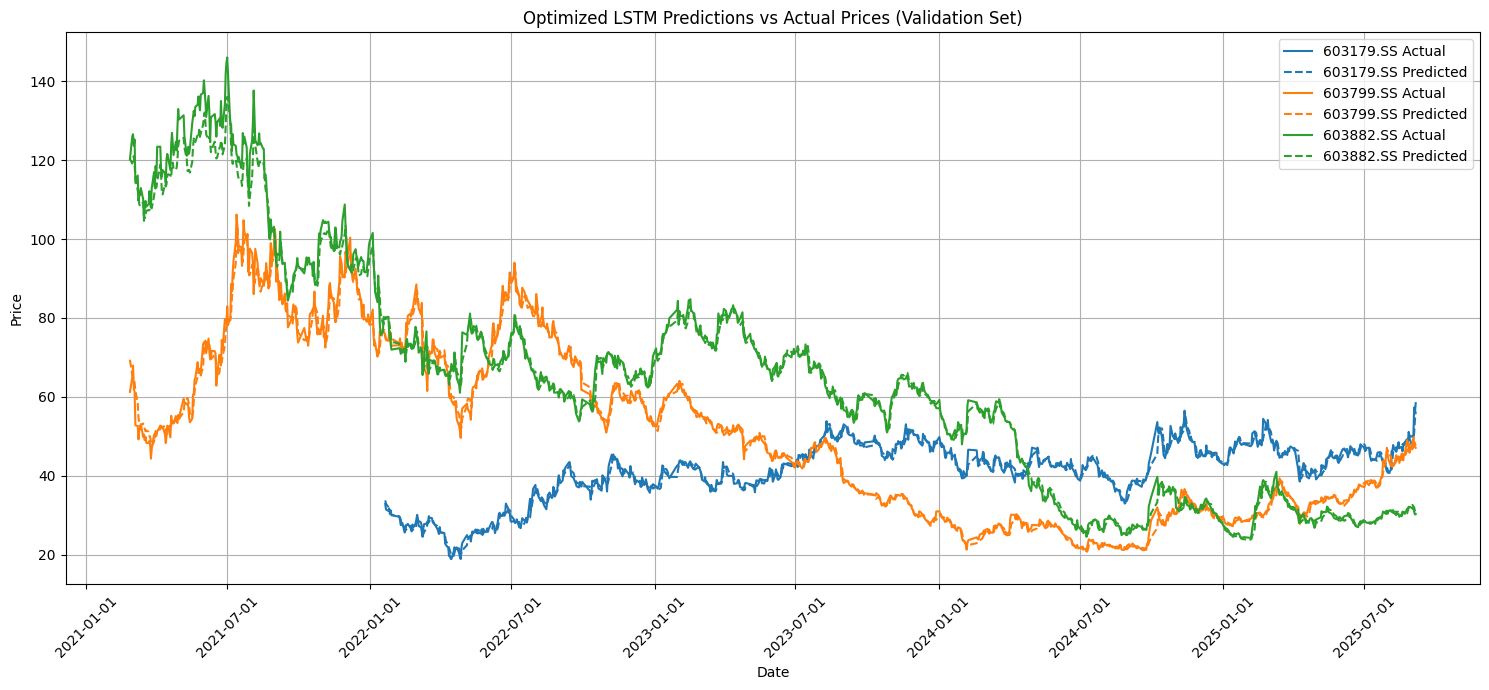

In [18]:
# Make predictions on the validation set using the optimized model
y_pred_optimized = model_optimized.predict(X_val)

# Inverse scale the predictions and actual values using the scaler fitted on the original combined_df 'Close' price
# Ensure the close_scaler is still available from previous steps, or refit it if necessary
if 'close_scaler' not in locals():
     print("close_scaler not found. Refitting close_scaler.")
     close_scaler = MinMaxScaler()
     close_scaler.fit(combined_df['Close'].values.reshape(-1, 1))

y_val_rescaled_optimized = close_scaler.inverse_transform(y_val.reshape(-1, 1))
y_pred_rescaled_optimized = close_scaler.inverse_transform(y_pred_optimized)

# Calculate and compare quantitative metrics (MSE and MAE)
mse_original = mean_squared_error(y_val_rescaled, y_pred_rescaled)
mae_original = mean_absolute_error(y_val_rescaled, y_pred_rescaled)

mse_optimized = mean_squared_error(y_val_rescaled_optimized, y_pred_rescaled_optimized)
mae_optimized = mean_absolute_error(y_val_rescaled_optimized, y_pred_rescaled_optimized)

print("--- Model Performance Comparison (Validation Set) ---")
print(f"Original Model MSE: {mse_original:.6f}")
print(f"Optimized Model MSE: {mse_optimized:.6f}")
print(f"Original Model MAE: {mae_original:.6f}")
print(f"Optimized Model MAE: {mae_optimized:.6f}")

# Plot the validation predictions of the optimized model
# Use the existing plot_validation_predictions function
print("\n--- Validation Predictions Plot (Optimized Model) ---")
plot_validation_predictions(y_val_rescaled_optimized.flatten(), y_pred_rescaled_optimized.flatten(), y_dates_val, tickers_val, title='Optimized LSTM Predictions vs Actual Prices (Validation Set)')


正在为 000821.SZ 生成未来预测 (优化模型)...
股票 000821.SZ 的未来预测 (优化模型):


,Date,Predicted Close (Optimized)
0,2025-09-06,13.280826
1,2025-09-07,13.455216
2,2025-09-08,13.715172
3,2025-09-09,14.078606
4,2025-09-10,14.515489
5,2025-09-11,14.982355
6,2025-09-12,15.440080


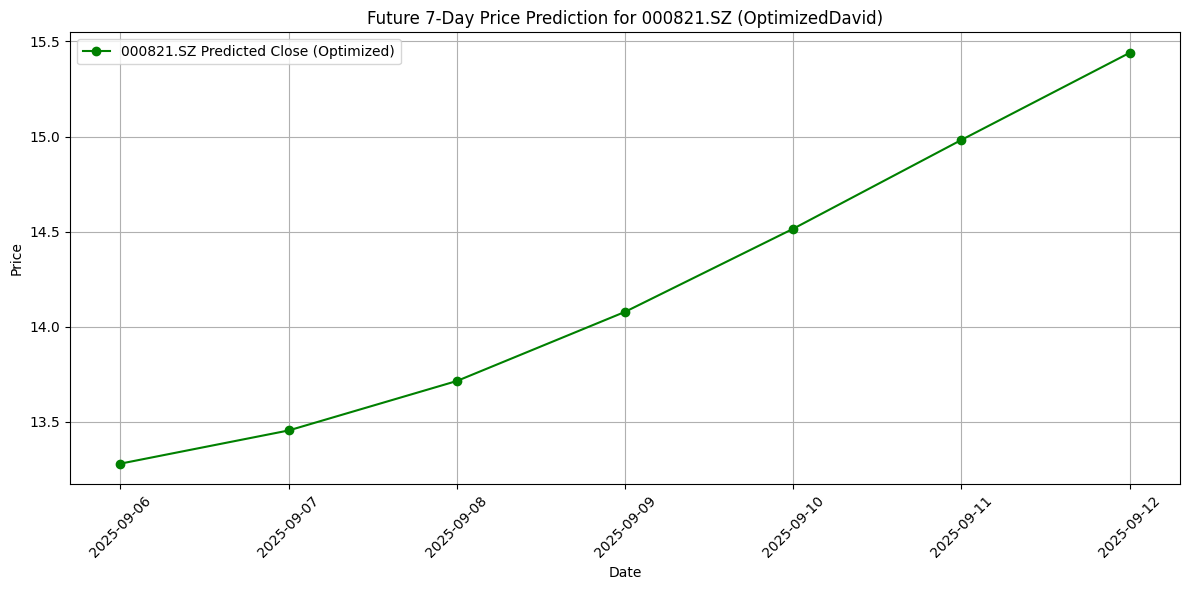


正在为 000980.SZ 生成未来预测 (优化模型)...
股票 000980.SZ 的未来预测 (优化模型):


,Date,Predicted Close (Optimized)
0,2025-09-06,2.129885
1,2025-09-07,1.918552
2,2025-09-08,2.033592
3,2025-09-09,2.384832
4,2025-09-10,2.858308
5,2025-09-11,3.362993
6,2025-09-12,3.840849


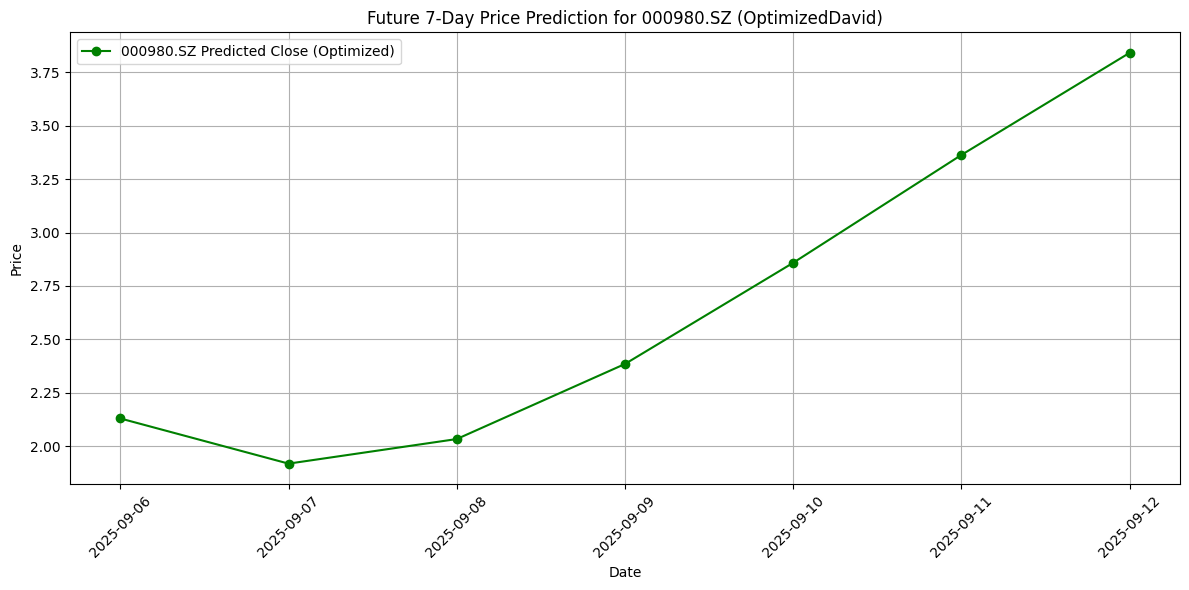


正在为 002073.SZ 生成未来预测 (优化模型)...
股票 002073.SZ 的未来预测 (优化模型):


,Date,Predicted Close (Optimized)
0,2025-09-06,7.487601
1,2025-09-07,7.504547
2,2025-09-08,7.781987
3,2025-09-09,8.211343
4,2025-09-10,8.687040
5,2025-09-11,9.140132
6,2025-09-12,9.537393


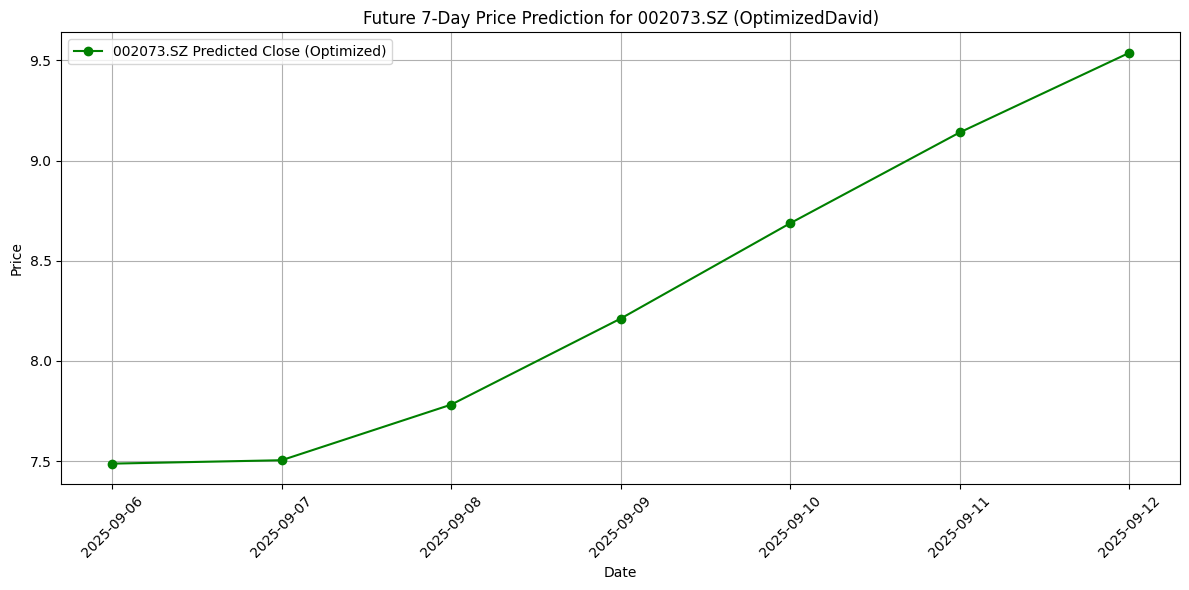


正在为 002240.SZ 生成未来预测 (优化模型)...
股票 002240.SZ 的未来预测 (优化模型):


,Date,Predicted Close (Optimized)
0,2025-09-06,16.920706
1,2025-09-07,17.372682
2,2025-09-08,17.926061
3,2025-09-09,18.495360
4,2025-09-10,19.027536
5,2025-09-11,19.499484
6,2025-09-12,19.906521


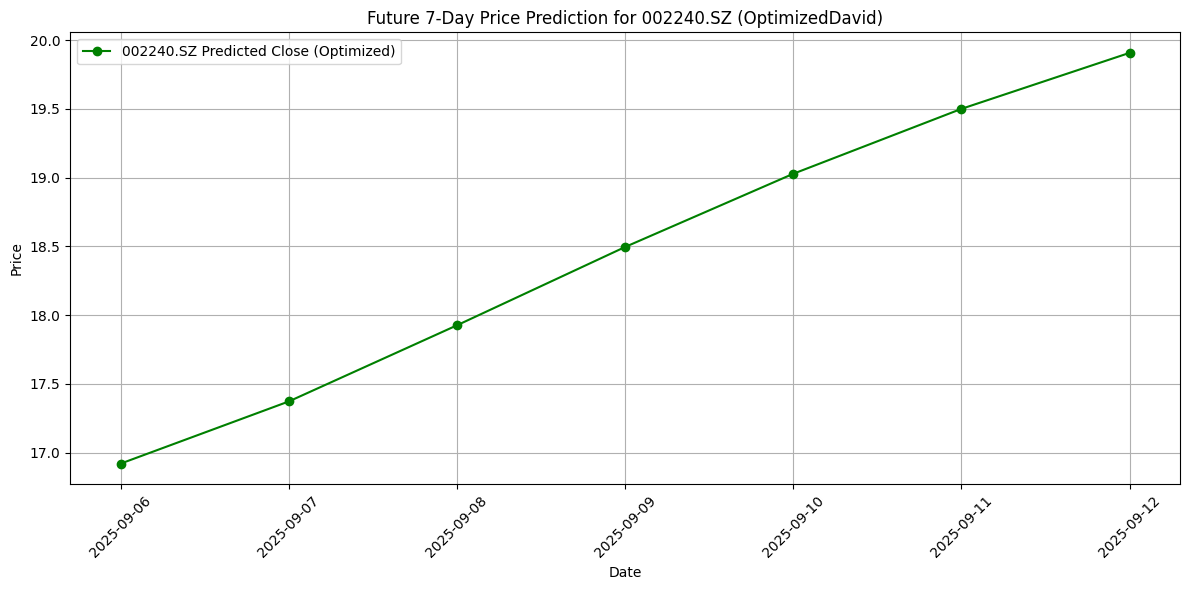


正在为 002364.SZ 生成未来预测 (优化模型)...
股票 002364.SZ 的未来预测 (优化模型):


,Date,Predicted Close (Optimized)
0,2025-09-06,23.720002
1,2025-09-07,23.940260
2,2025-09-08,24.587254
3,2025-09-09,25.373178
4,2025-09-10,26.117402
5,2025-09-11,26.743595
6,2025-09-12,27.241097


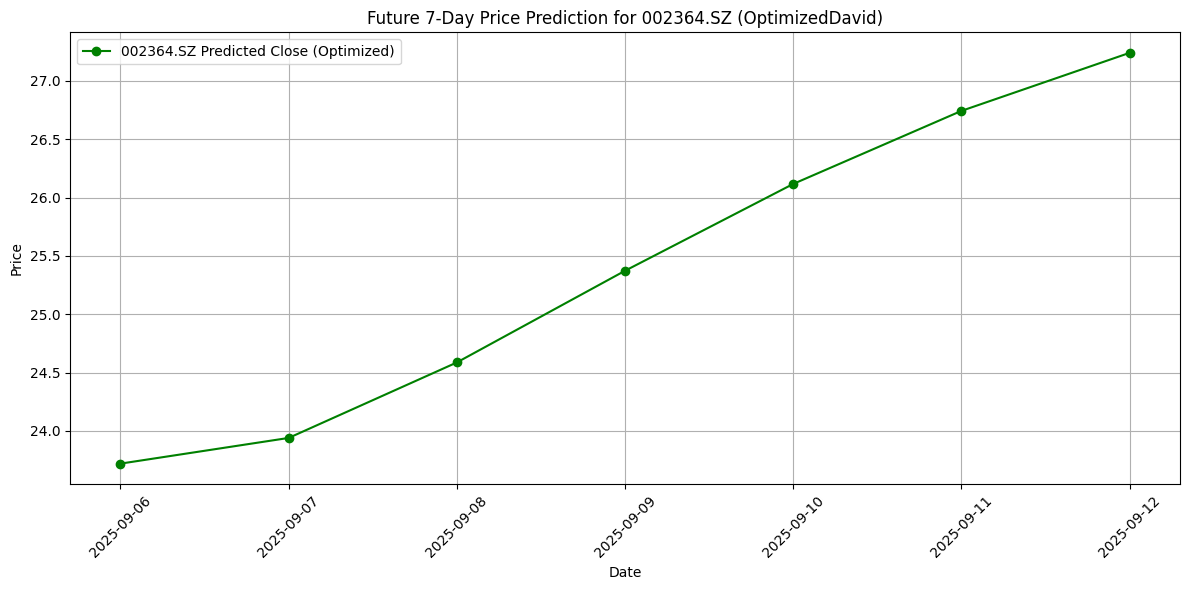


正在为 002459.SZ 生成未来预测 (优化模型)...
股票 002459.SZ 的未来预测 (优化模型):


,Date,Predicted Close (Optimized)
0,2025-09-06,13.145851
1,2025-09-07,13.608471
2,2025-09-08,14.076458
3,2025-09-09,14.538909
4,2025-09-10,14.987767
5,2025-09-11,15.415412
6,2025-09-12,15.813962


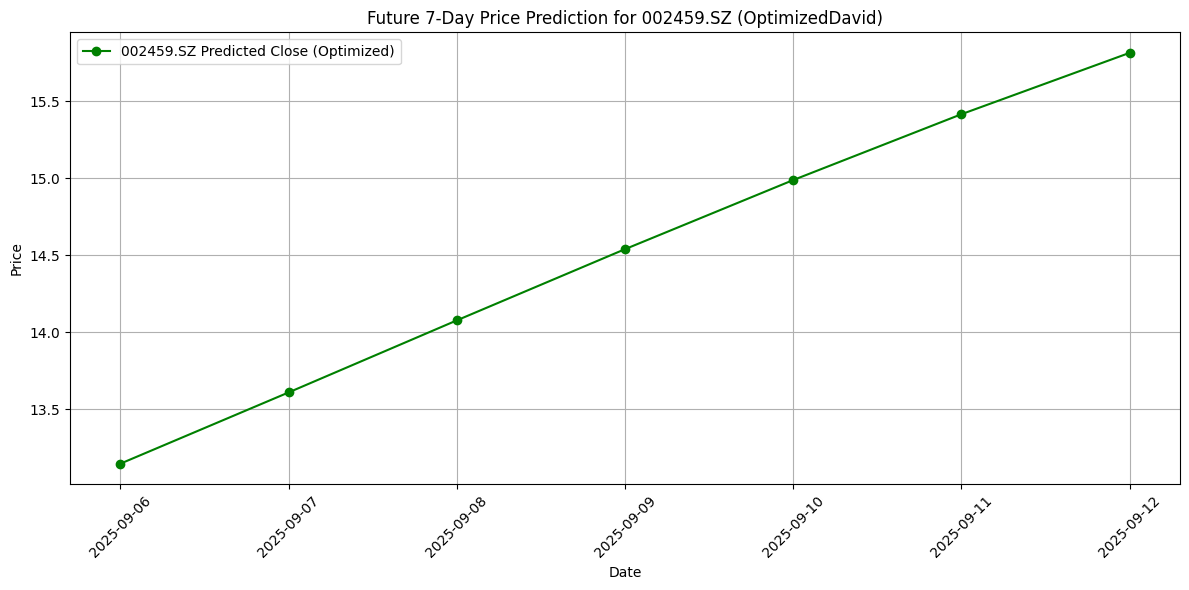


正在为 600211.SS 生成未来预测 (优化模型)...
股票 600211.SS 的未来预测 (优化模型):


,Date,Predicted Close (Optimized)
0,2025-09-06,48.732702
1,2025-09-07,49.592219
2,2025-09-08,50.578418
3,2025-09-09,51.479448
4,2025-09-10,52.216608
5,2025-09-11,52.795383
6,2025-09-12,53.251402


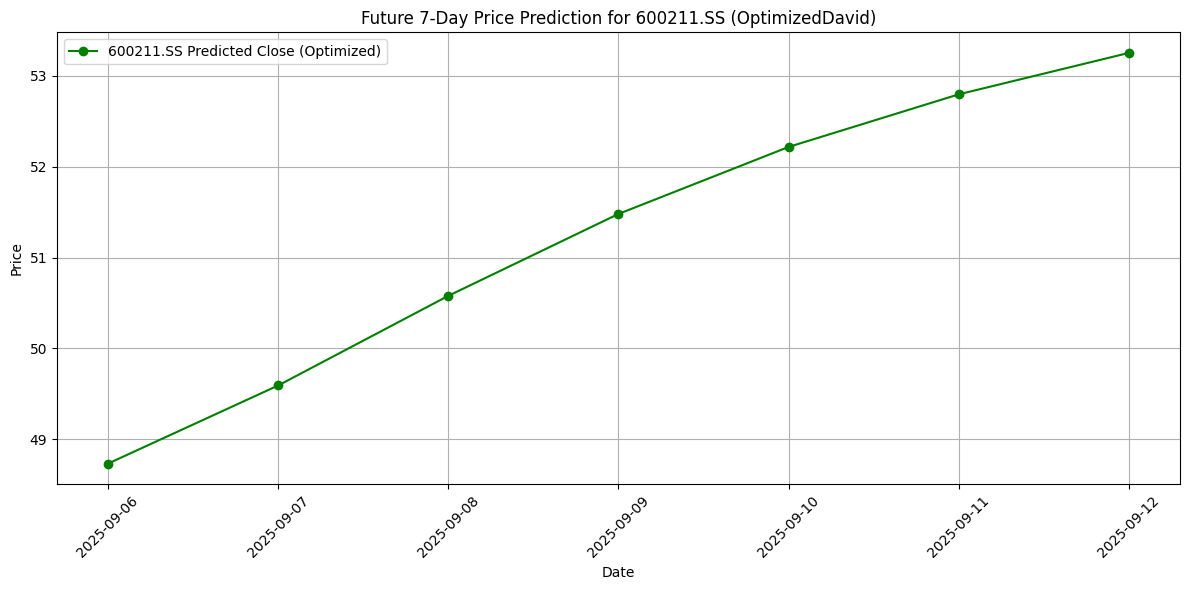


正在为 600233.SS 生成未来预测 (优化模型)...
股票 600233.SS 的未来预测 (优化模型):


,Date,Predicted Close (Optimized)
0,2025-09-06,17.206686
1,2025-09-07,17.369966
2,2025-09-08,17.708381
3,2025-09-09,18.160554
4,2025-09-10,18.658105
5,2025-09-11,19.148987
6,2025-09-12,19.601135


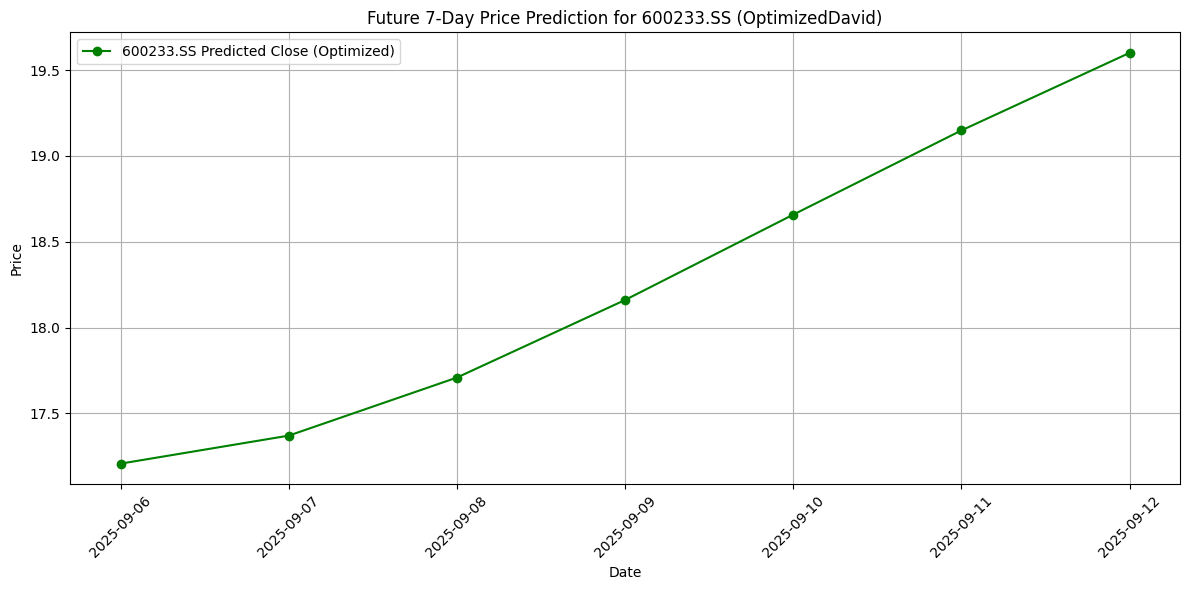


正在为 600699.SS 生成未来预测 (优化模型)...
股票 600699.SS 的未来预测 (优化模型):


,Date,Predicted Close (Optimized)
0,2025-09-06,21.773446
1,2025-09-07,22.493638
2,2025-09-08,23.270606
3,2025-09-09,23.985551
4,2025-09-10,24.596151
5,2025-09-11,25.103426
6,2025-09-12,25.524269


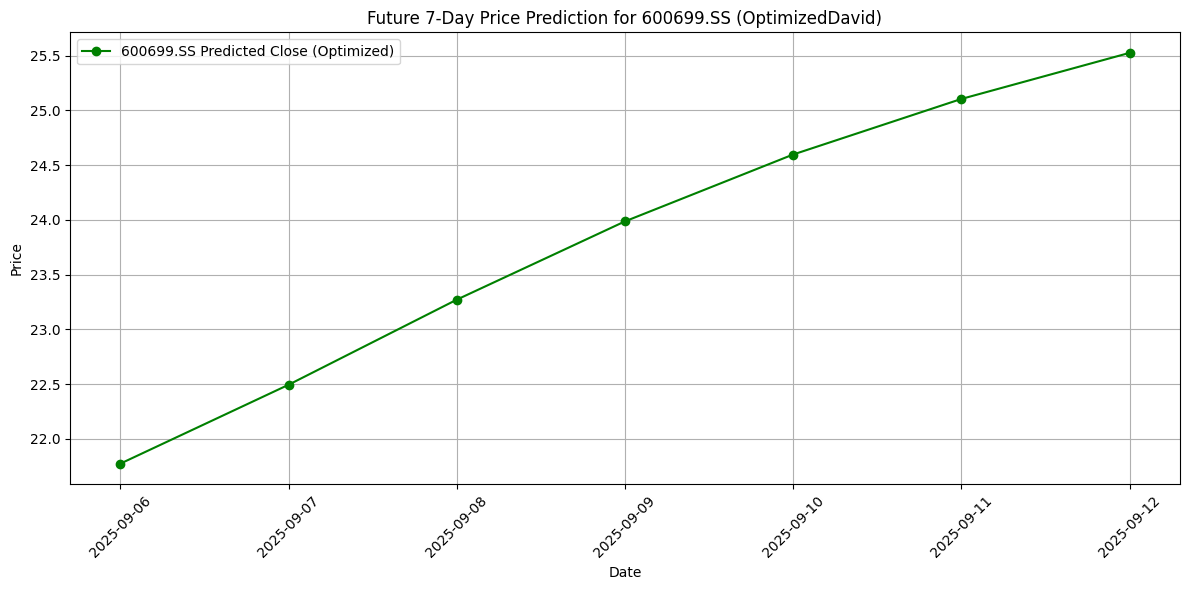


正在为 601615.SS 生成未来预测 (优化模型)...
股票 601615.SS 的未来预测 (优化模型):


,Date,Predicted Close (Optimized)
0,2025-09-06,11.701968
1,2025-09-07,12.054385
2,2025-09-08,12.609249
3,2025-09-09,13.216922
4,2025-09-10,13.777585
5,2025-09-11,14.249333
6,2025-09-12,14.628722


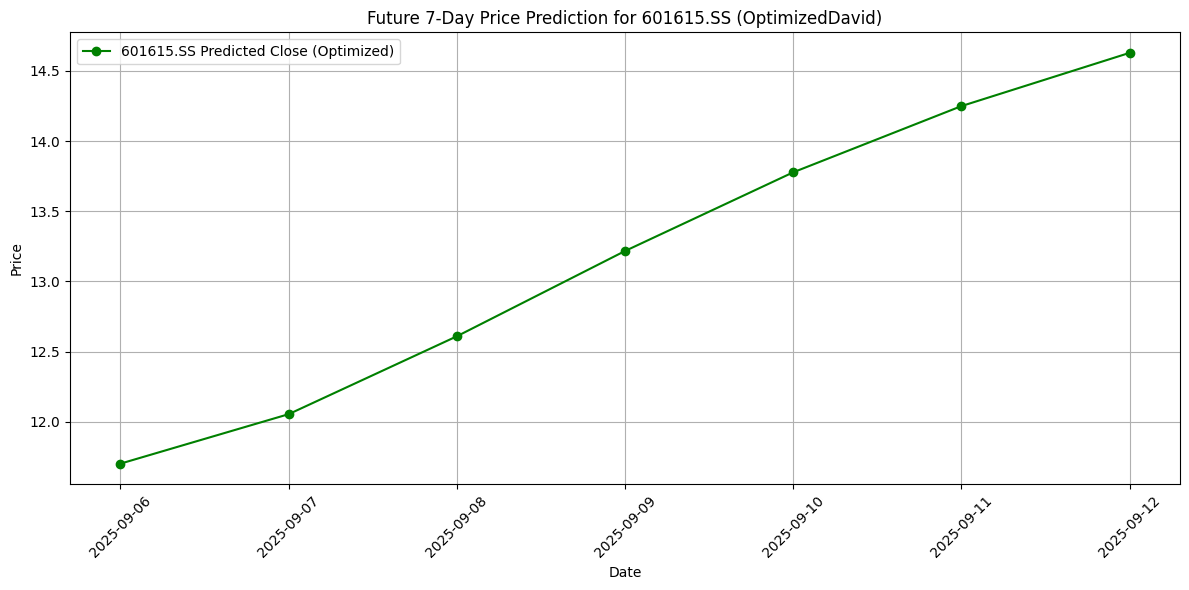


正在为 601689.SS 生成未来预测 (优化模型)...
股票 601689.SS 的未来预测 (优化模型):


,Date,Predicted Close (Optimized)
0,2025-09-06,63.789904
1,2025-09-07,63.933540
2,2025-09-08,64.789861
3,2025-09-09,65.793469
4,2025-09-10,66.656717
5,2025-09-11,67.315697
6,2025-09-12,67.808943


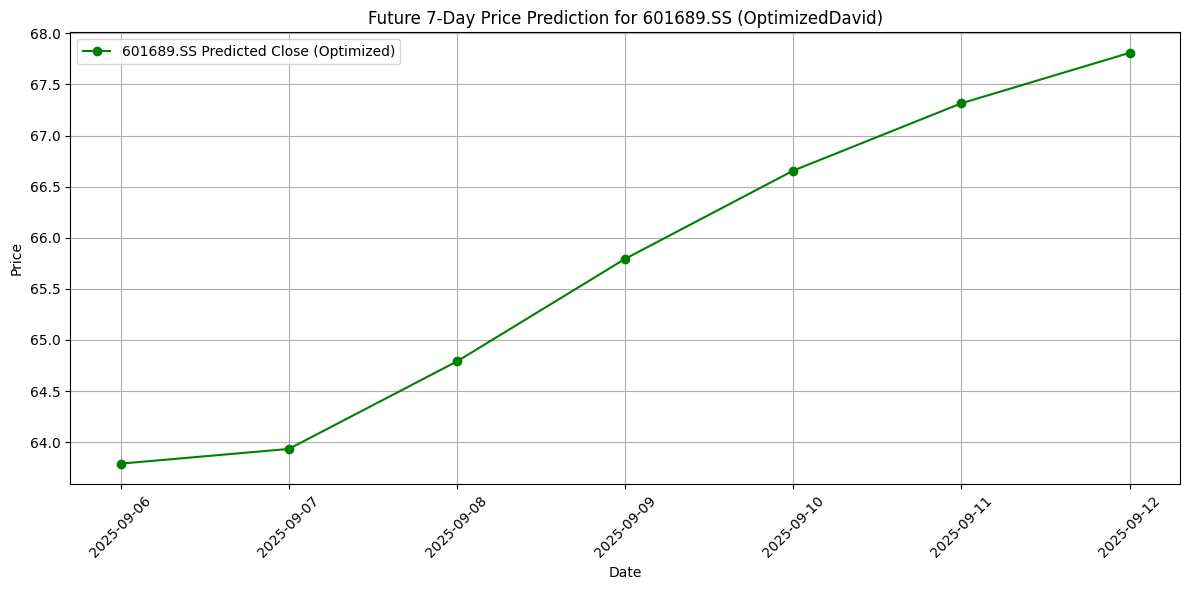


正在为 603179.SS 生成未来预测 (优化模型)...
股票 603179.SS 的未来预测 (优化模型):


,Date,Predicted Close (Optimized)
0,2025-09-06,59.559229
1,2025-09-07,62.019358
2,2025-09-08,63.521484
3,2025-09-09,64.395324
4,2025-09-10,64.986241
5,2025-09-11,65.490354
6,2025-09-12,65.969808


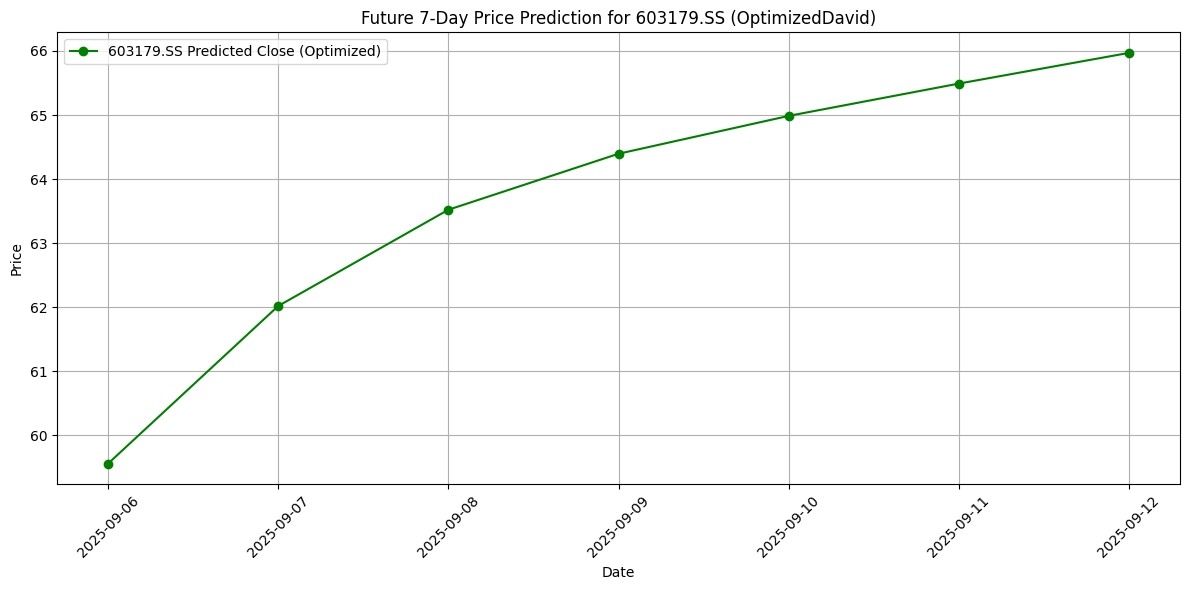


正在为 603799.SS 生成未来预测 (优化模型)...
股票 603799.SS 的未来预测 (优化模型):


,Date,Predicted Close (Optimized)
0,2025-09-06,48.280869
1,2025-09-07,49.509810
2,2025-09-08,50.714780
3,2025-09-09,51.671442
4,2025-09-10,52.370816
5,2025-09-11,52.885126
6,2025-09-12,53.286936


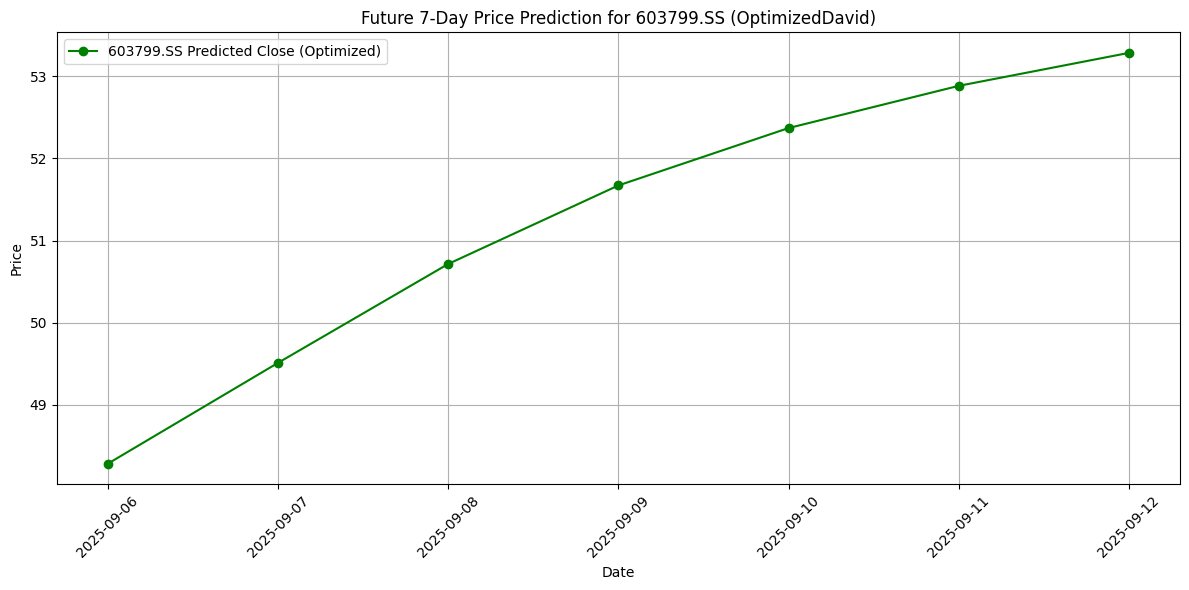


正在为 603882.SS 生成未来预测 (优化模型)...
股票 603882.SS 的未来预测 (优化模型):


,Date,Predicted Close (Optimized)
0,2025-09-06,30.343005
1,2025-09-07,30.745849
2,2025-09-08,31.418459
3,2025-09-09,32.154694
4,2025-09-10,32.836151
5,2025-09-11,33.417581
6,2025-09-12,33.896121


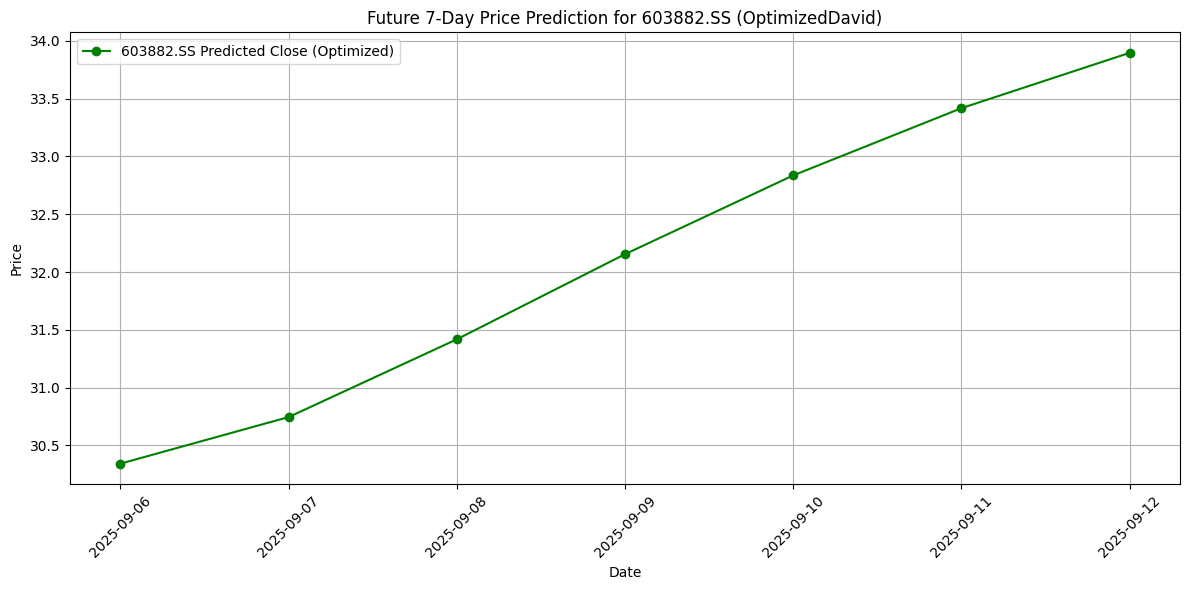


已完成对所有数据充足的股票的未来预测 (优化模型)。


In [19]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib

# Configure matplotlib for Chinese display if needed (copying from previous cell for robustness)
# matplotlib.rcParams['font.sans-serif'] = ['SimHei']
matplotlib.rcParams['axes.unicode_minus'] = False

# Generate future predictions and plots for each ticker with enough data using the optimized model

# Get the list of unique tickers
unique_tickers = combined_df['Ticker'].unique()

for ticker_to_predict in unique_tickers:
    print(f"\n正在为 {ticker_to_predict} 生成未来预测 (优化模型)...")

    # Get the last sequence of data for the current ticker
    last_sequence_df = combined_df[combined_df['Ticker'] == ticker_to_predict].tail(window_size).copy()

    if len(last_sequence_df) < window_size:
        print(f"股票 {ticker_to_predict} 的数据不足，无法创建大小为 {window_size} 的序列。跳过对该股票的未来预测。")
        continue

    # Scale the last sequence using the scaler fitted on the entire data
    last_sequence_scaled = scaler.transform(last_sequence_df[features])

    future_preds_scaled_optimized = []
    current_sequence = last_sequence_scaled.copy()

    # Predict future 7 days (using the optimized model)
    num_future_days = 7
    for _ in range(num_future_days):
        input_seq = current_sequence.reshape(1, window_size, len(features))
        # Use the optimized model for prediction
        pred_scaled = model_optimized.predict(input_seq, verbose=0)[0, 0]
        future_preds_scaled_optimized.append(pred_scaled)

        # Create a new row with the predicted close price and other features (using last known values as a simple approach)
        new_row_scaled = np.copy(current_sequence[-1, :])
        new_row_scaled[features.index('Close')] = pred_scaled

        # Append the new row and remove the oldest row
        current_sequence = np.vstack([current_sequence[1:], new_row_scaled])


    # Inverse scale the future predictions (only the Close price)
    future_preds_scaled_optimized_array = np.array(future_preds_scaled_optimized).reshape(-1, 1)
    dummy_features = np.zeros((len(future_preds_scaled_optimized_array), len(features)-1))
    inverse_transform_input = np.hstack([dummy_features[:, :features.index('Close')],
                                         future_preds_scaled_optimized_array,
                                         dummy_features[:, features.index('Close'):]])

    # Use the scaler fitted on the entire 'Close' price data for inverse transformation
    future_rescaled_optimized = close_scaler.inverse_transform(inverse_transform_input)[:, features.index('Close')]


    # Generate future dates for the predicted number of days
    last_date = last_sequence_df['Date'].iloc[-1]
    future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=num_future_days, freq='D')

    print(f"股票 {ticker_to_predict} 的未来预测 (优化模型):")
    # Create a DataFrame to display future predictions with dates
    future_predictions_df_optimized = pd.DataFrame({'Date': future_dates, 'Predicted Close (Optimized)': future_rescaled_optimized})
    display(future_predictions_df_optimized)


    # Plotting future predictions
    plt.figure(figsize=(12, 6))
    plt.plot(future_dates, future_rescaled_optimized, label=f'{ticker_to_predict} Predicted Close (Optimized)', color='green', marker='o')

    plt.title(f'Future {num_future_days}-Day Price Prediction for {ticker_to_predict} (OptimizedDavid)')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.grid(True)
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

print("\n已完成对所有数据充足的股票的未来预测 (优化模型)。")